In [367]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from statsmodels.api import OLS
from sklearn.linear_model import LinearRegression
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from functools import partial
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import \
     (Stepwise,
      sklearn_selected,
      sklearn_selection_path)
import seaborn as sns
from itertools import combinations
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [368]:
Hitters = load_data ('Hitters')
Hitters = Hitters.dropna() # 결측값 있는 행 전체 제거
Hitters.shape

(263, 20)

In [369]:
Hitters.columns

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'League', 'Division',
       'PutOuts', 'Assists', 'Errors', 'Salary', 'NewLeague'],
      dtype='object')

In [370]:
Hitters

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [371]:
X = Hitters[[
    'AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 
       'PutOuts', 'Assists', 'Errors', 'Salary',
]]

# 5. 상수항 추가
X_with_const = sm.add_constant(X)

# 6. VIF 계산
vif_df = pd.DataFrame()
vif_df["Variable"] = X_with_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                 for i in range(X_with_const.shape[1])]
vif_df
# 누적 vs 시즌으로 나눠서 할 필요가 있음 + 비율형 파생 변수를 생성해서 다중공선성을 낮춰야됌

,Variable,VIF
0,const,18.141176
1,AtBat,23.575591
2,Hits,31.382277
3,HmRun,7.640442
4,Runs,15.147427
5,RBI,11.688507
6,Walks,4.276099
7,Years,9.127860
8,CAtBat,251.755741
9,CHits,495.673344


C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2

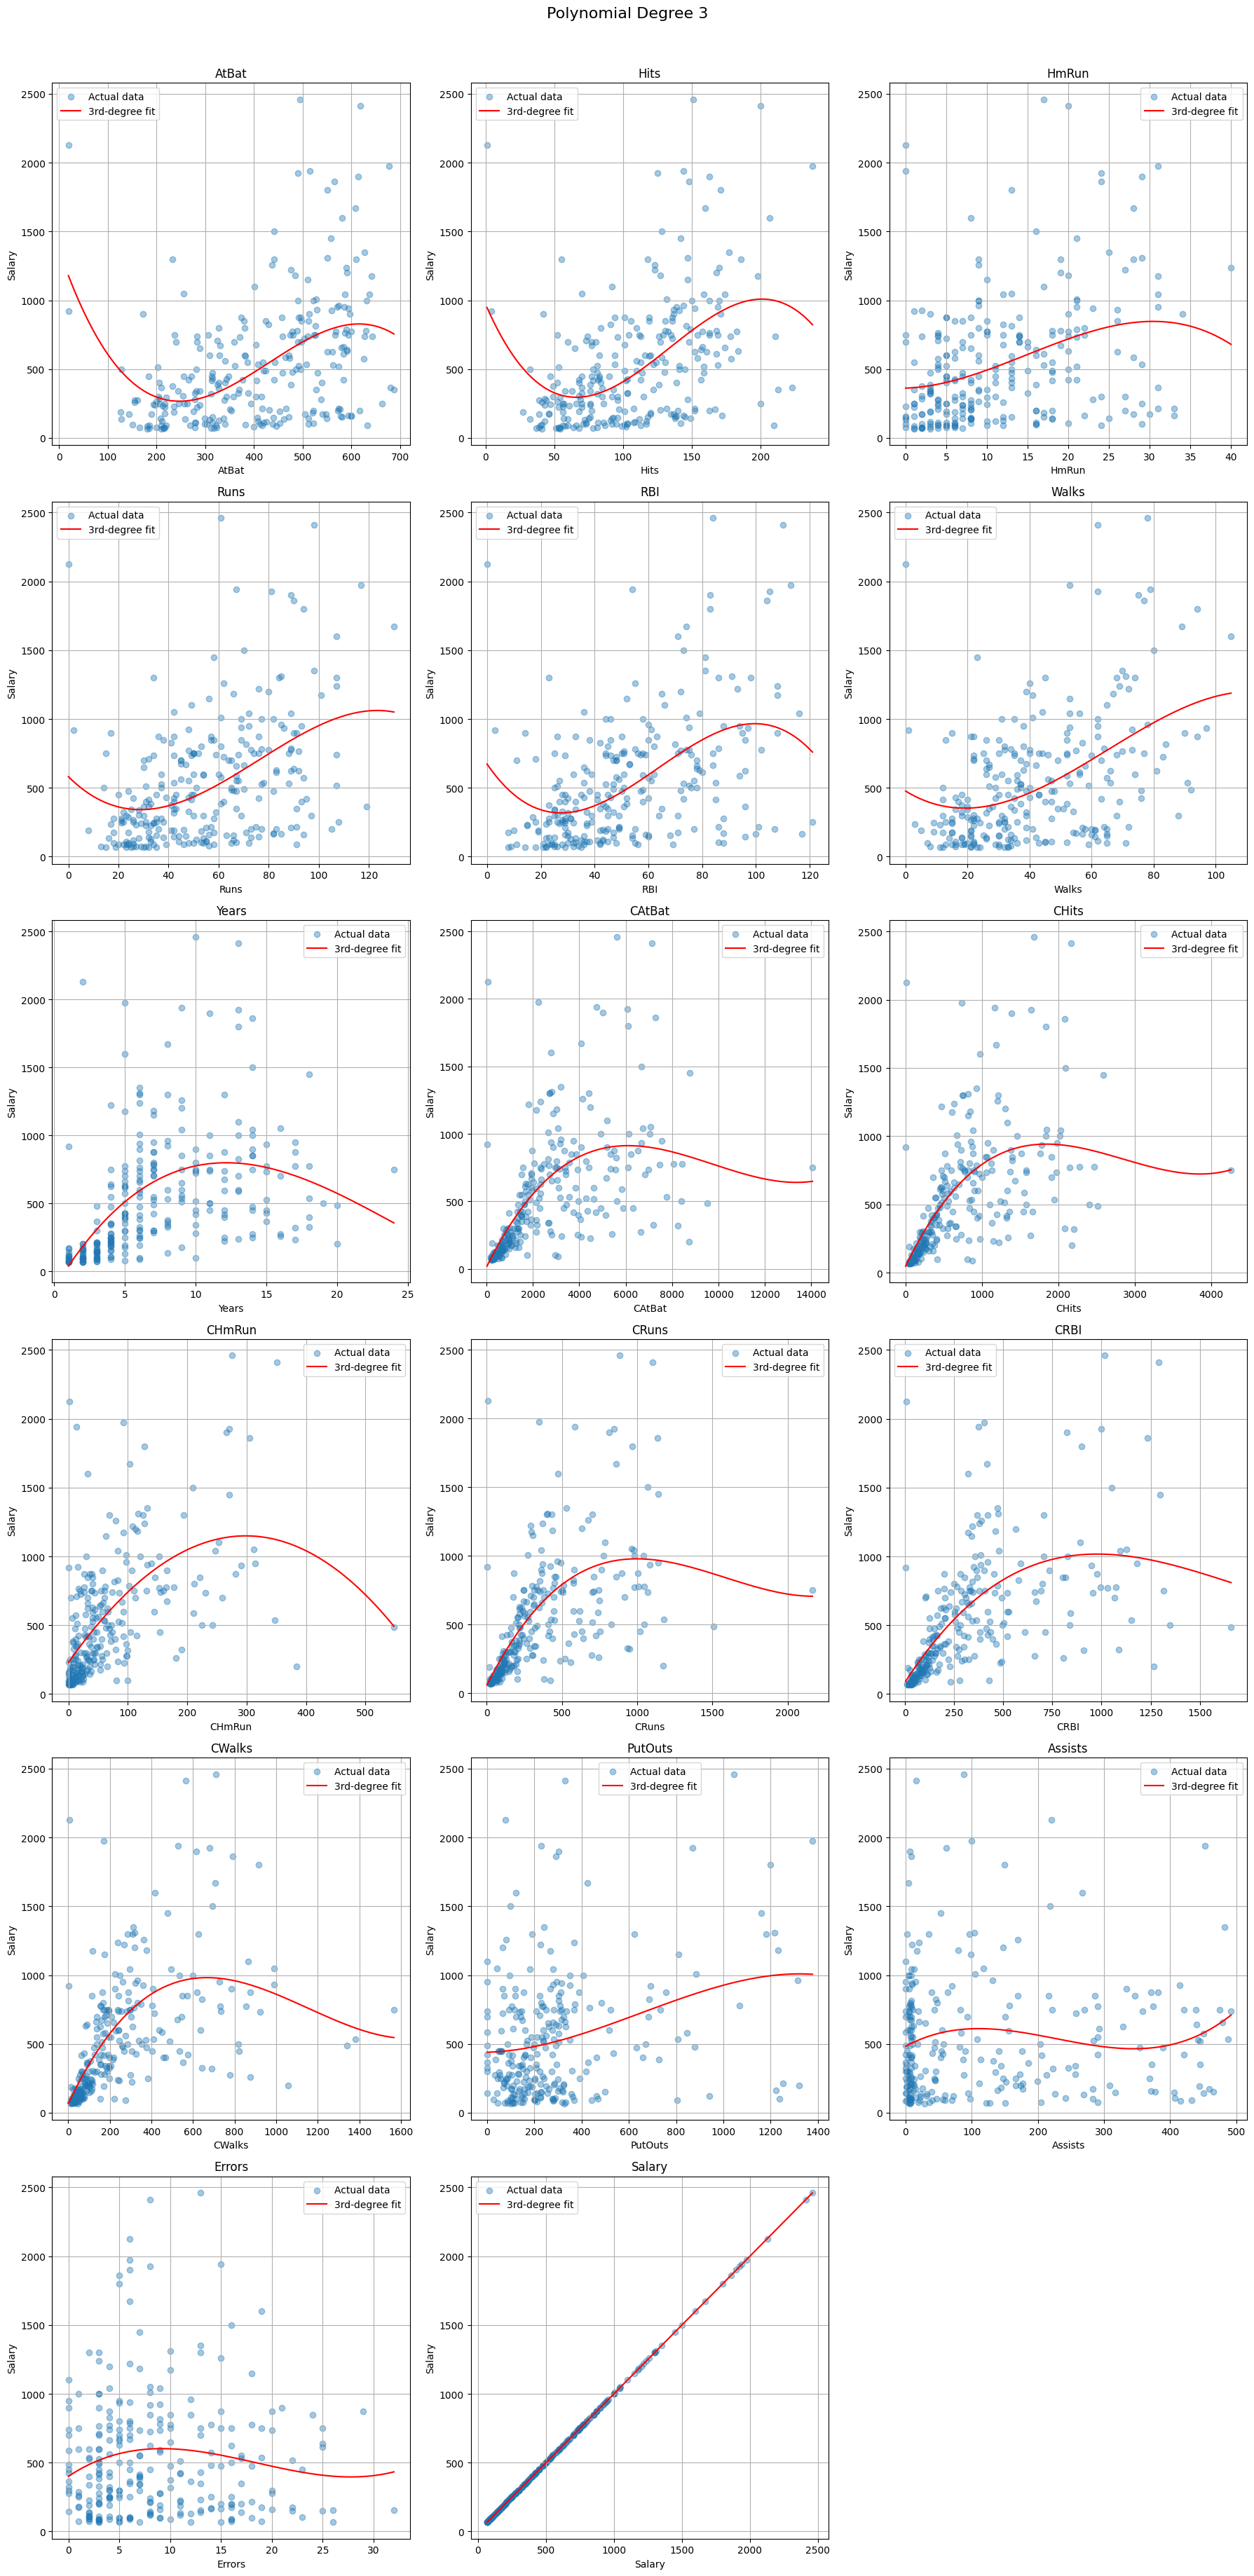

In [372]:
features = ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 
       'PutOuts', 'Assists', 'Errors', 'Salary', ]

y = Hitters['Salary']

# subplot 구성
n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 6))
axes = axes.flatten()

# 각 변수에 대해 반복
for i, feature in enumerate(features):
    x = Hitters[[feature]]
    
    # 다항 특성 생성 및 모델 학습
    poly = PolynomialFeatures(degree=3)
    X_poly = poly.fit_transform(x)
    model = LinearRegression().fit(X_poly, y)

    # 시각화용 x 구간
    x_plot = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    x_poly_plot = poly.transform(x_plot)
    y_plot = model.predict(x_poly_plot)

    # 플롯 그리기
    ax = axes[i]
    ax.scatter(x, y, alpha=0.4, label='Actual data')
    ax.plot(x_plot, y_plot, color='red', label='3rd-degree fit')
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel('Salary')
    ax.legend()
    ax.grid(True)

# 남은 빈 plot 지우기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Polynomial Degree 3", fontsize=16, y=1.02)
plt.show()

In [373]:
def nCp(sigma2, estimator, X, Y):
    "Negative Cp statistic"
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    return -(RSS + 2 * p * sigma2) / n 

In [374]:
design = MS(Hitters.columns.drop('Salary')).fit(Hitters)
Y = np.array(Hitters['Salary'])
X = design.transform(Hitters)
sigma2 = OLS(Y,X).fit().scale

In [375]:
neg_Cp = partial(nCp, sigma2)

In [376]:
strategy = Stepwise.first_peak(design,
                               direction='forward',
                               max_terms=len(design.terms))


In [377]:
hitters_Cp = sklearn_selected(OLS,
                               strategy,
                               scoring=neg_Cp)
hitters_Cp.fit(Hitters, Y)
hitters_Cp.selected_state_


('Assists',
 'AtBat',
 'CAtBat',
 'CRBI',
 'CRuns',
 'CWalks',
 'Division',
 'Hits',
 'PutOuts',
 'Walks')

In [378]:
# nCp를 통해 선택된 변수들만 가지고 salary MLR 실행

# 독립 변수: nCp선택된 변수만을 사용
selected_features = [
  'Assists',
 'AtBat',
 'CAtBat',
 'CRBI',
 'CRuns',
 'CWalks',
 'Division',
 'Hits',
 'PutOuts',
 'Walks'
]


# 디자인 행렬 생성

y = Hitters['Salary']
X = MS(selected_features).fit_transform(Hitters)

# 회귀 모델 적합
model = sm.OLS(y, X)
results = model.fit()

# 결과 요약 출력
summarize(results)
#변수	계수	해석 (단위당 연봉 영향)
#intercept	162.54	기준선 연봉 (해석 불필요)
#AtBat	-2.17	시즌 타석 1회 증가 시 연봉 $2,169 감소
#CAtBat	-0.13	커리어 타석 1회 증가 시 연봉 $130 감소
#CRBI	+0.77	커리어 타점 1점 증가 시 $774 증가
#CRuns	+1.41	커리어 득점 1점 증가 시 $1,408 증가
#CWalks	-0.83	커리어 볼넷 1회 증가 시 $831 감소
#Division[W]	-112.38	서부지구 소속이면 연봉이 $112,380 낮음
#Hits	+6.92	시즌 안타 1개 증가 시 $6,918 증가
#PutOuts	+0.30	수비 아웃 1회 증가 시 $297 증가
#Walks	+5.77	시즌 볼넷 1개 증가 시 $5,773 증가

,coef,std err,t,P>|t|
intercept,162.5354,66.908,2.429,0.016
Assists,0.2832,0.158,1.796,0.074
AtBat,-2.1687,0.536,-4.044,0.000
CAtBat,-0.1301,0.055,-2.344,0.020
CRBI,0.7743,0.210,3.694,0.000
CRuns,1.4082,0.390,3.607,0.000
CWalks,-0.8308,0.264,-3.152,0.002
Division[W],-112.3801,39.214,-2.866,0.005
Hits,6.9180,1.647,4.201,0.000
PutOuts,0.2974,0.074,3.995,0.000


In [379]:
X = Hitters[[
    'Assists',
 'AtBat',
 'CAtBat',
 'CRBI',
 'CRuns',
 'CWalks',
 'Hits',
 'PutOuts',
 'Walks'
]]

# 5. 상수항 추가
X_with_const = sm.add_constant(X)

# 6. VIF 계산
vif_df = pd.DataFrame()
vif_df["Variable"] = X_with_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                 for i in range(X_with_const.shape[1])]
vif_df
#변수들 간 중복 설명(공선성)이 너무 심해서
#모델이 계수의 방향도 왜곡하고
#예측력(R²)은 좋아 보여도 해석력이 무너지는 상태

,Variable,VIF
0,const,11.106367
1,Assists,1.407313
2,AtBat,16.681318
3,CAtBat,42.752853
4,CRBI,12.379089
5,CRuns,44.477236
6,CWalks,13.042267
7,Hits,14.709368
8,PutOuts,1.169786
9,Walks,3.192022


In [380]:
Hitters['LogSalary'] = np.log(Hitters['Salary'])

In [381]:
design = MS(Hitters.columns.drop(['LogSalary', 'Salary'])).fit(Hitters)
Y = np.array(Hitters['LogSalary'])
X = design.transform(Hitters)
sigma2 = OLS(Y, X).fit().scale

In [382]:
neg_Cp = partial(nCp, sigma2)

In [383]:
hitters_Cp = sklearn_selected(OLS,
                               strategy,
                               scoring=neg_Cp)
hitters_Cp.fit(Hitters, Y)
hitters_Cp.selected_state_

('AtBat',
 'CRuns',
 'CWalks',
 'Division',
 'Hits',
 'League',
 'PutOuts',
 'Walks',
 'Years')

In [384]:
# nCp를 통해 선택된 변수들만 가지고 Logsalary MLR 실행

# 독립 변수: nCp선택된 변수만을 사용
selected_features = [
 'AtBat',
 'CRuns',
 'CWalks',
 'Division',
 'Hits',
 'League',
 'PutOuts',
 'Walks',
 'Years'
]


# 디자인 행렬 생성

y = Hitters['LogSalary']
X = MS(selected_features).fit_transform(Hitters)

# 회귀 모델 적합
model = sm.OLS(y, X)
results = model.fit()

# 결과 요약 출력
summarize(results)
#Intercept	4.5448 기준 연봉 ≈ exp(4.5448) ≈ $94.1K
#AtBat	-0.0025	타석 1회 증가 시 연봉 약 0.25% 감소
#CRuns	+0.0013	커리어 득점 1점 증가 시 연봉 약 0.13% 증가
#CWalks	-0.0011	커리어 볼넷 1회 증가 시 연봉 약 0.11% 감소
#Division[W]	-0.1603	0.035	서부 지구 선수는 연봉 약 14.8% 낮음 (exp(-0.1603) ≈ 0.852)
#Hits	+0.0116	안타 1개 증가 시 연봉 약 1.17% 증가
#PutOuts	+0.0003	수비 포지션 처리 1회 증가 시 연봉 약 0.03% 증가
#Walks	+0.0100	볼넷 1개 증가 시 연봉 약 1.01% 증가
#Years	+0.0640	경력 1년 증가 시 연봉 약 6.6% 증가

,coef,std err,t,P>|t|
intercept,4.5448,0.164,27.689,0.000
AtBat,-0.0025,0.001,-2.450,0.015
CRuns,0.0013,0.000,3.154,0.002
CWalks,-0.0011,0.001,-2.230,0.027
Division[W],-0.1603,0.076,-2.114,0.035
Hits,0.0116,0.003,3.637,0.000
League[N],0.1101,0.077,1.438,0.152
PutOuts,0.0003,0.000,2.188,0.030
Walks,0.0100,0.003,3.343,0.001
Years,0.0640,0.018,3.488,0.001


In [385]:
Hitters2 = load_data ('Hitters')
Hitters2 = Hitters2.dropna() # 결측값 있는 행 전체 제거

#  누적 기록 기반 비율 변수 생성
Hitters2['CHits_per_CAtBat'] = Hitters2['CHits'] / Hitters2['CAtBat']
Hitters2['CHmRun_per_CAtBat'] = Hitters2['CHmRun'] / Hitters2['CAtBat']
Hitters2['CRBI_per_CAtBat'] = Hitters2['CRBI'] / Hitters2['CAtBat']
Hitters2['CWalks_per_CAtBat'] = Hitters2['CWalks'] / Hitters2['CAtBat']
Hitters2['CRuns_per_CAtBat'] = Hitters2['CRuns'] / Hitters2['CAtBat']

#  연평균 수비 지표 생성
Hitters2['PutOuts_per_Year'] = Hitters2['PutOuts'] / Hitters2['Years']
Hitters2['Assists_per_Year'] = Hitters2['Assists'] / Hitters2['Years']
Hitters2['Errors_per_Year'] = Hitters2['Errors'] / Hitters2['Years']


In [386]:
Hitters2 = Hitters2.drop(columns=['AtBat', 'Hits', 'HmRun','Runs', 'RBI','Walks','CAtBat','CHits', 'CHmRun','CRuns', 'CRBI','CWalks', 'PutOuts', 'Assists' , 'Errors'])

In [387]:
Hitters2

,Years,League,Division,Salary,NewLeague,CHits_per_CAtBat,CHmRun_per_CAtBat,CRBI_per_CAtBat,CWalks_per_CAtBat,CRuns_per_CAtBat,PutOuts_per_Year,Assists_per_Year,Errors_per_Year
1,14,N,W,475.0,N,0.242099,0.020006,0.120035,0.108727,0.093070,45.142857,3.071429,0.714286
2,3,A,W,480.0,A,0.281404,0.038793,0.163793,0.161946,0.137931,293.333333,27.333333,4.666667
3,11,N,E,500.0,N,0.279851,0.039979,0.148898,0.062900,0.147122,18.181818,1.000000,0.272727
4,2,N,E,91.5,N,0.255051,0.030303,0.116162,0.083333,0.121212,402.500000,20.000000,2.000000
5,11,A,W,750.0,A,0.257033,0.004310,0.076225,0.044011,0.113657,25.636364,38.272727,2.272727
...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,5,N,E,700.0,N,0.298187,0.011839,0.115057,0.051054,0.140215,65.000000,1.800000,0.600000
318,12,A,E,875.0,A,0.274179,0.007077,0.081836,0.158773,0.162765,26.083333,31.750000,1.666667
319,6,A,W,385.0,A,0.254706,0.004118,0.054706,0.085882,0.127647,6.166667,18.833333,1.166667
320,8,A,E,960.0,A,0.267980,0.030331,0.131332,0.103815,0.146967,164.250000,16.375000,1.500000


In [388]:
# Hitters2 MLR
y = Hitters2['Salary']

# 독립 변수: Salary 제외한 모든 열 사용
features = list(Hitters2.columns.difference(['Salary']))

# 디자인 행렬 생성
X = MS(features).fit_transform(Hitters2)

# 회귀 모델 적합
model = sm.OLS(y, X)
results3 = model.fit()

# 결과 요약 출력
summarize(results3)
#변수	계수(β)	p-value	해석
#Intercept	-1592.70	0.000	기준선 (모든 변수가 0일 때 연봉), 해석 필요 없음
#Assists_per_Year	+1.691	0.014	연간 어시스트 1개 증가 → 연봉 $1,691 증가
#CHits_per_CAtBat	+4773.98	0.001	누적 타율 0.01 증가 → 연봉 $47,740 증가
#CRBI_per_CAtBat	+3496.49	0.037	누적 타점률 0.01 증가 → 연봉 $34,965 증가
#CRuns_per_CAtBat	+3150.61	0.032	누적 득점률 0.01 증가 → 연봉 $31,506 증가
#Division[W]	-125.18	0.006	서부지구 소속 → 연봉 $125,176 낮음
#Errors_per_Year	-28.19	0.011	연간 실책 1개 증가 → 연봉 $28,187 감소
#Years	+20.996	0.000	경력 1년 증가 → 연봉 $20,996 증가

,coef,std err,t,P>|t|
intercept,-1592.6983,282.607,-5.636,0.000
Assists_per_Year,1.6910,0.685,2.467,0.014
CHits_per_CAtBat,4773.9796,1399.278,3.412,0.001
CHmRun_per_CAtBat,-532.4283,3526.799,-0.151,0.880
CRBI_per_CAtBat,3496.4874,1668.334,2.096,0.037
CRuns_per_CAtBat,3150.6092,1463.012,2.154,0.032
CWalks_per_CAtBat,-260.6894,813.695,-0.320,0.749
Division[W],-125.1765,44.922,-2.787,0.006
Errors_per_Year,-28.1869,10.975,-2.568,0.011
League[N],17.1536,87.786,0.195,0.845


In [389]:
X = Hitters2[[
    'CHits_per_CAtBat', 'CHmRun_per_CAtBat', 'CRBI_per_CAtBat',
    'CWalks_per_CAtBat', 'PutOuts_per_Year', 'Assists_per_Year',
    'Errors_per_Year', 'Years', 'CRuns_per_CAtBat'
]]

# 5. 상수항 추가
X_with_const = sm.add_constant(X)

# 6. VIF 계산
vif_df = pd.DataFrame()
vif_df["Variable"] = X_with_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                 for i in range(X_with_const.shape[1])]
vif_df

#홈런은 결국 타점에 들어가있음 따라서 홈런 지표를 지우고 타점만 반영해도 이 안해 홈런은 전부 들어가 있음

,Variable,VIF
0,const,156.926006
1,CHits_per_CAtBat,2.230168
2,CHmRun_per_CAtBat,6.073790
3,CRBI_per_CAtBat,5.974417
4,CWalks_per_CAtBat,1.503969
5,PutOuts_per_Year,1.394328
6,Assists_per_Year,2.286169
7,Errors_per_Year,2.659486
8,Years,1.586329
9,CRuns_per_CAtBat,2.172515


In [390]:
# Hitters2 MLR
y = Hitters2['Salary']

# 독립 변수: Salary, 'CHmRun_per_CAtBat' 제외한 모든 열 사용
features = list(Hitters2.columns.difference(['Salary', 'CHmRun_per_CAtBat','NewLeague']))

# 디자인 행렬 생성
X = MS(features).fit_transform(Hitters2)

# 회귀 모델 적합
model = sm.OLS(y, X)
results3 = model.fit()

# 결과 요약 출력
summarize(results3)

#통계적으로 유의한 변수들 (p-value < 0.05)
#Intercept	-1588.66 기준값 (해석 불필요)
#Assists_per_Year	+1.7274	연간 어시스트 1개 증가 → 연봉 $1,727 증가
#CHits_per_CAtBat	+4955.94 누적타율 0.01 증가 → 연봉 $49,559 증가
#CRBI_per_CAtBat	+3230.91 누적 타점률 0.01 증가 → 연봉 $32,309 증가
#CRuns_per_CAtBat	+2922.26 누적 득점률 0.01 증가 → 연봉 $29,223 증가
#Division[W]	-126.02	서부 지구 소속 → 연봉 $126,017 낮음
#Errors_per_Year	-28.58 실책 1개 증가 → 연봉 $28,576 감소
#Years	+21.01	경력 1년 증가 → 연봉 $21,012 증가

,coef,std err,t,P>|t|
intercept,-1600.6322,278.254,-5.752,0.000
Assists_per_Year,1.7070,0.674,2.533,0.012
CHits_per_CAtBat,4905.1619,1173.095,4.181,0.000
CRBI_per_CAtBat,3266.4336,765.569,4.267,0.000
CRuns_per_CAtBat,3025.6104,1256.314,2.408,0.017
CWalks_per_CAtBat,-223.9953,783.495,-0.286,0.775
Division[W],-125.5343,44.674,-2.810,0.005
Errors_per_Year,-28.2780,10.915,-2.591,0.010
League[N],25.6391,44.766,0.573,0.567
PutOuts_per_Year,-0.0170,0.219,-0.078,0.938


In [391]:
X = Hitters2[[
    'CHits_per_CAtBat',  'CRBI_per_CAtBat',
    'CWalks_per_CAtBat',  'CRuns_per_CAtBat','PutOuts_per_Year', 'Assists_per_Year',
    'Errors_per_Year', 'Years',
]]

# 5. 상수항 추가
X_with_const = sm.add_constant(X)

# 6. VIF 계산
vif_df = pd.DataFrame()
vif_df["Variable"] = X_with_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                 for i in range(X_with_const.shape[1])]
vif_df

,Variable,VIF
0,const,154.129850
1,CHits_per_CAtBat,1.591193
2,CRBI_per_CAtBat,1.266065
3,CWalks_per_CAtBat,1.403357
4,CRuns_per_CAtBat,1.608195
5,PutOuts_per_Year,1.394282
6,Assists_per_Year,2.226344
7,Errors_per_Year,2.650843
8,Years,1.569040


In [392]:
Hitters2['LogSalary'] = np.log(Hitters2['Salary'])

In [393]:
# Hitters2 MLR
y = Hitters2['LogSalary']

# 독립 변수: Salary, 'CHmRun_per_CAtBat' 제외한 모든 열 사용
features = ['Assists_per_Year', 'CHits_per_CAtBat', 'CRBI_per_CAtBat','CRuns_per_CAtBat',
            'CWalks_per_CAtBat', 'Division', 'Errors_per_Year',
            'League',  'PutOuts_per_Year', 'Years']

# 디자인 행렬 생성
X = MS(features).fit_transform(Hitters2)

# 회귀 모델 적합
model = sm.OLS(y, X)
results3 = model.fit()

# 결과 요약 출력
summarize(results3)

#변수	계수(β)	p-value	해석 (exp(β) - 1 ≈ % 변화)
#Intercept	1.9300	0.000	기준 연봉 ≈ exp(1.93) ≈ $6,891
#Assists_per_Year	0.0035	0.004	연간 어시스트 1개 증가 → 연봉 +0.35% 증가
#CHits_per_CAtBat	9.3008	0.000	누적  타율이 0.01 증가 → 연봉 +144% 증가 (exp(0.093) ≈ 1.097)
#CRBI_per_CAtBat	5.0609	0.000	누적타점률이 0.01 증가 → 연봉 +52% 증가
#CRuns_per_CAtBat	5.9466	0.009	누적 득점률이 0.01 증가 → 연봉 +63% 증가
#Division[W]	-0.1703	0.036	서부지구 소속이면 연봉 -15.6% 감소 (exp(-0.1703) ≈ 0.843)
#Errors_per_Year	-0.0796	0.000	연간 실책 1개 증가 → 연봉 -7.7% 감소
#Years	0.0615	0.000	경력 1년 증가 → 연봉 +6.3% 증가

,coef,std err,t,P>|t|
intercept,1.9300,0.502,3.846,0.000
Assists_per_Year,0.0035,0.001,2.912,0.004
CHits_per_CAtBat,9.3008,2.116,4.396,0.000
CRBI_per_CAtBat,5.0609,1.381,3.666,0.000
CRuns_per_CAtBat,5.9466,2.266,2.625,0.009
CWalks_per_CAtBat,-1.3727,1.413,-0.972,0.332
Division[W],-0.1703,0.081,-2.113,0.036
Errors_per_Year,-0.0796,0.020,-4.044,0.000
League[N],0.0671,0.081,0.831,0.407
PutOuts_per_Year,-0.0002,0.000,-0.388,0.698


C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2

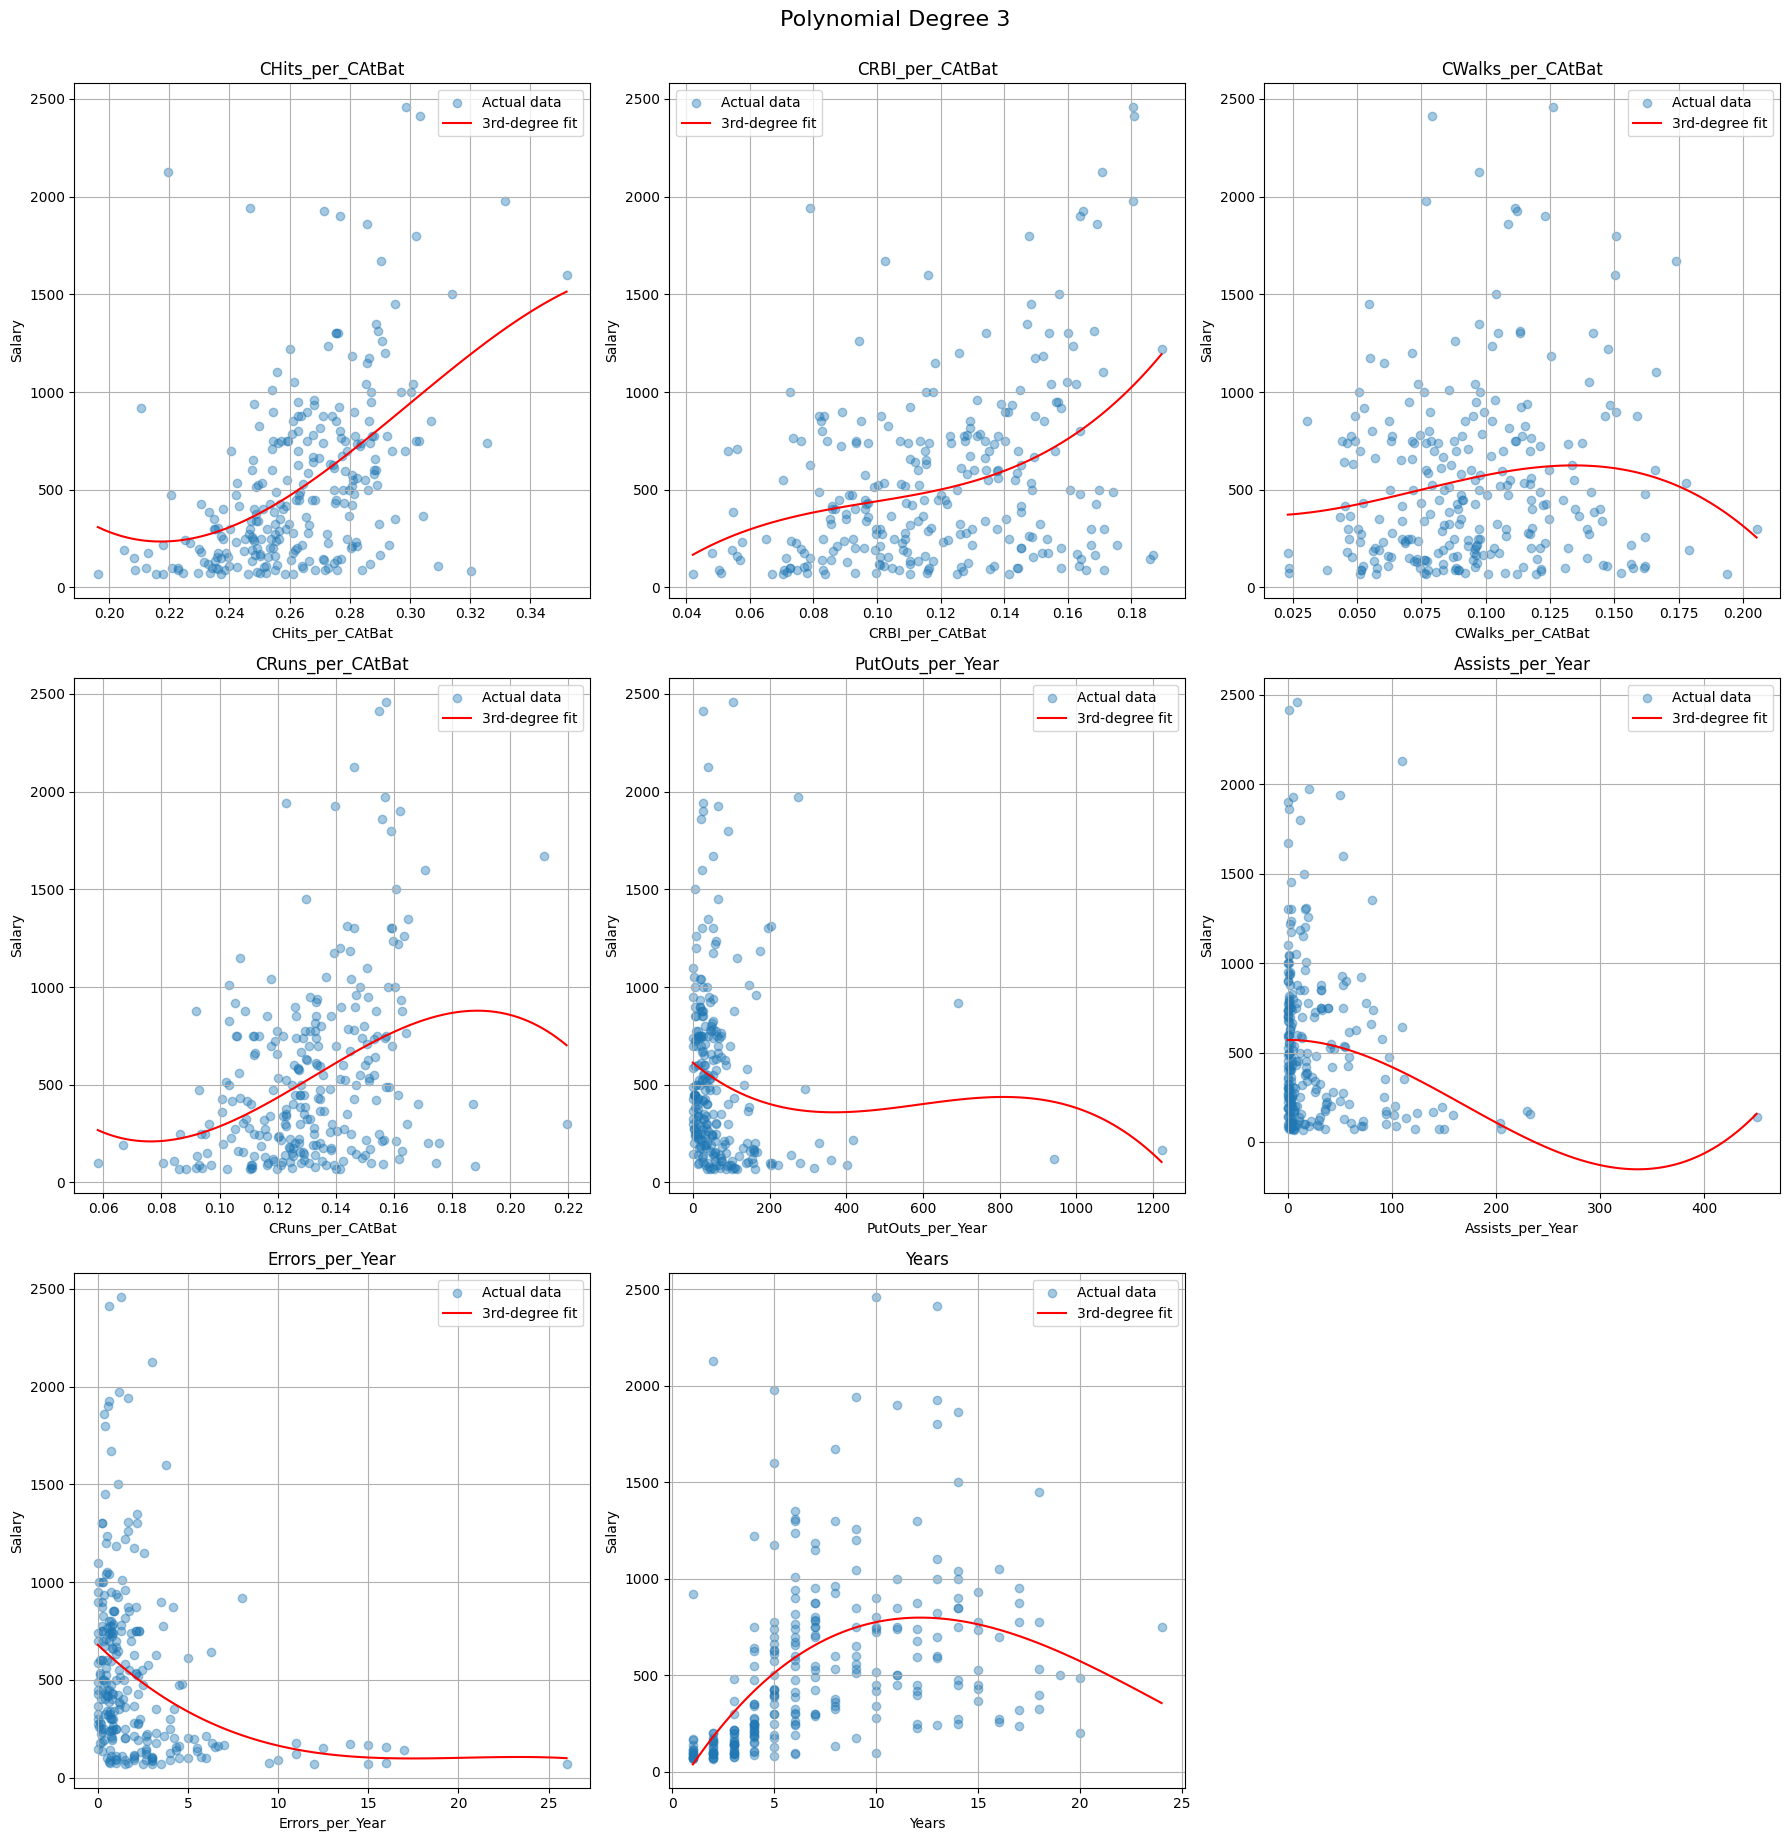

In [394]:
features = ['CHits_per_CAtBat', 'CRBI_per_CAtBat', 'CWalks_per_CAtBat','CRuns_per_CAtBat',
            'PutOuts_per_Year', 'Assists_per_Year', 'Errors_per_Year',
            'Years']

y = Hitters2['Salary']

# subplot 구성
n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 6))
axes = axes.flatten()

# 각 변수에 대해 반복
for i, feature in enumerate(features):
    x = Hitters2[[feature]]
    
    # 다항 특성 생성 및 모델 학습
    poly = PolynomialFeatures(degree=3)
    X_poly = poly.fit_transform(x)
    model = LinearRegression().fit(X_poly, y)

    # 시각화용 x 구간
    x_plot = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    x_poly_plot = poly.transform(x_plot)
    y_plot = model.predict(x_poly_plot)

    # 플롯 그리기
    ax = axes[i]
    ax.scatter(x, y, alpha=0.4, label='Actual data')
    ax.plot(x_plot, y_plot, color='red', label='3rd-degree fit')
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel('Salary')
    ax.legend()
    ax.grid(True)

# 남은 빈 plot 지우기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Polynomial Degree 3", fontsize=16, y=1.02)
plt.show()

C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2

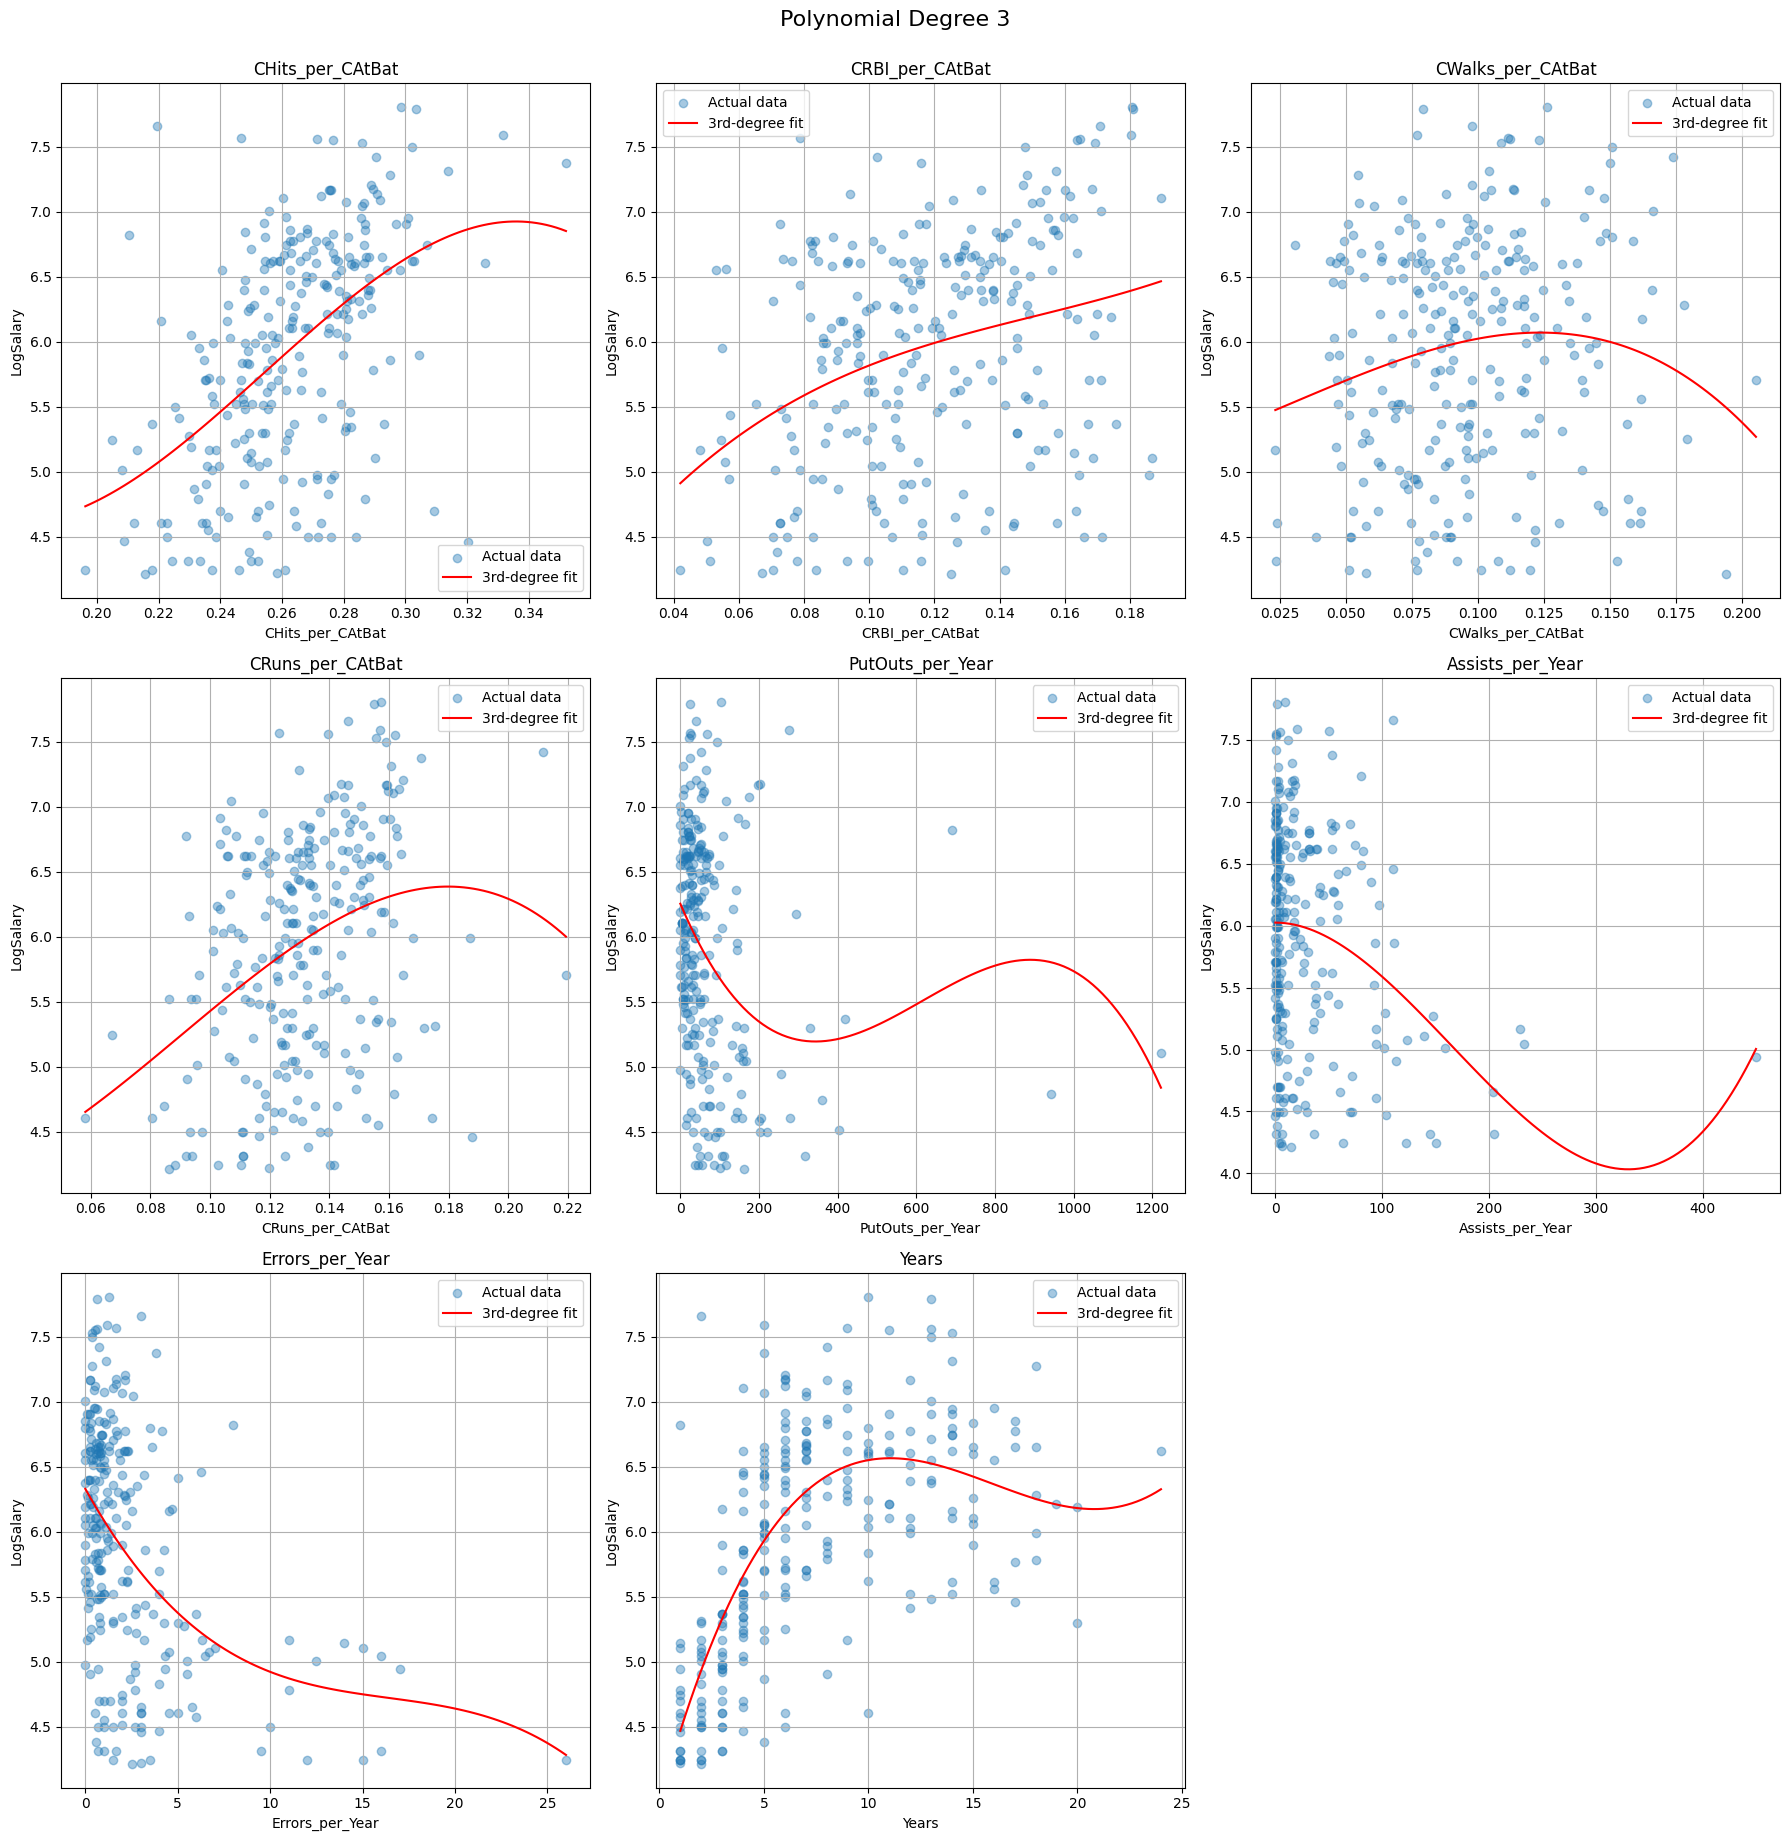

In [395]:
features = ['CHits_per_CAtBat', 'CRBI_per_CAtBat', 'CWalks_per_CAtBat','CRuns_per_CAtBat',
            'PutOuts_per_Year', 'Assists_per_Year', 'Errors_per_Year',
            'Years']

y = Hitters2['LogSalary']

# subplot 구성
n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 6))
axes = axes.flatten()

# 각 변수에 대해 반복
for i, feature in enumerate(features):
    x = Hitters2[[feature]]
    
    # 다항 특성 생성 및 모델 학습
    poly = PolynomialFeatures(degree=3)
    X_poly = poly.fit_transform(x)
    model = LinearRegression().fit(X_poly, y)

    # 시각화용 x 구간
    x_plot = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    x_poly_plot = poly.transform(x_plot)
    y_plot = model.predict(x_poly_plot)

    # 플롯 그리기
    ax = axes[i]
    ax.scatter(x, y, alpha=0.4, label='Actual data')
    ax.plot(x_plot, y_plot, color='red', label='3rd-degree fit')
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel('LogSalary')
    ax.legend()
    ax.grid(True)

# 남은 빈 plot 지우기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Polynomial Degree 3", fontsize=16, y=1.02)
plt.show()

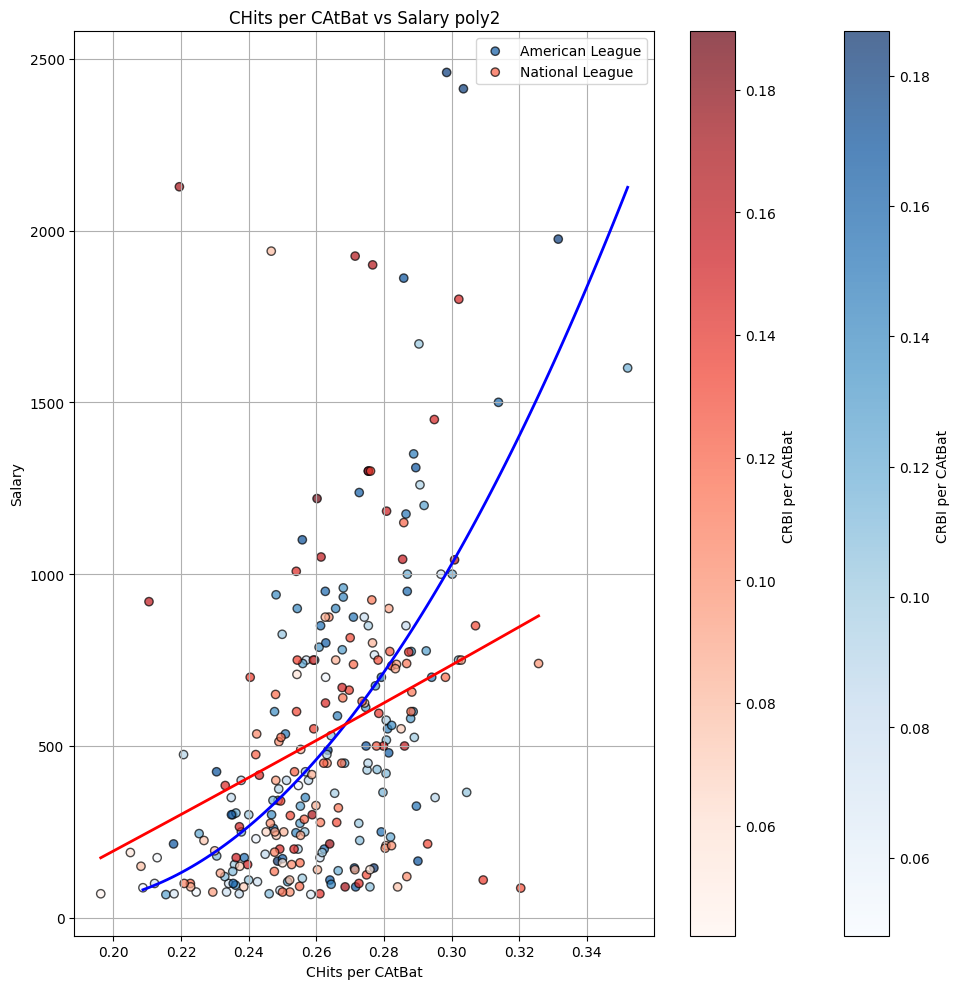

In [396]:


amer = Hitters2[Hitters2['League'] == 'A']
nati = Hitters2[Hitters2['League'] == 'N']

# 4. 산점도 시각화 (색은 타점률 기반)
plt.figure(figsize=(10, 10))

# 아메리칸 리그
amer_scatter = plt.scatter(amer["CHits_per_CAtBat"], amer["Salary"],
                           c=amer["CRBI_per_CAtBat"], cmap="Blues", label="American League",
                           alpha=0.7, edgecolor="k")

# 내셔널 리그
nati_scatter = plt.scatter(nati["CHits_per_CAtBat"], nati["Salary"],
                           c=nati["CRBI_per_CAtBat"], cmap="Reds", label="National League",
                           alpha=0.7, edgecolor="k")

# 회귀선 그리기 (2차)
x_amer = np.linspace(amer["CHits_per_CAtBat"].min(), amer["CHits_per_CAtBat"].max(), 100)
y_amer = np.polyval(np.polyfit(amer["CHits_per_CAtBat"], amer["Salary"], 2), x_amer)
plt.plot(x_amer, y_amer, color='blue', linewidth=2)

x_nati = np.linspace(nati["CHits_per_CAtBat"].min(), nati["CHits_per_CAtBat"].max(), 100)
y_nati = np.polyval(np.polyfit(nati["CHits_per_CAtBat"], nati["Salary"], 2), x_nati)
plt.plot(x_nati, y_nati, color='red', linewidth=2)

# 컬러바 추가
cbar = plt.colorbar(amer_scatter)
cbar1 = plt.colorbar(nati_scatter)
cbar.set_label("CRBI per CAtBat ")
cbar1.set_label("CRBI per CAtBat ")


# 라벨링
plt.xlabel("CHits per CAtBat")
plt.ylabel("Salary")
plt.title("CHits per CAtBat vs Salary poly2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

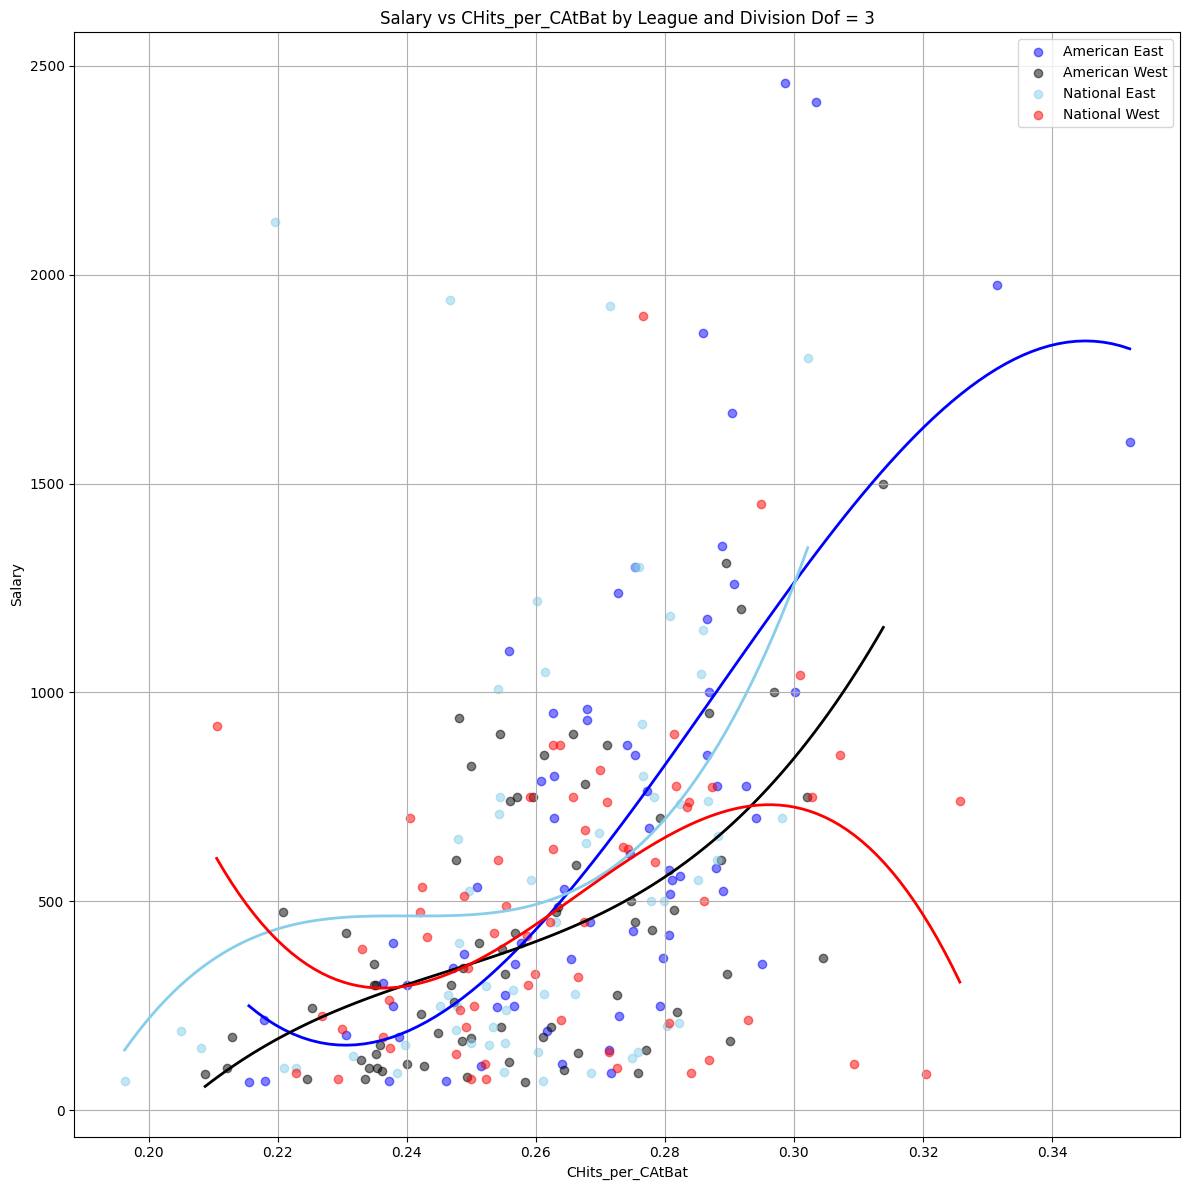

In [397]:
groups = {
    "American_East": Hitters2[(Hitters2['League'] == 'A') & (Hitters2['Division'] == 'E')],
    "American_West": Hitters2[(Hitters2['League'] == 'A') & (Hitters2['Division'] == 'W')],
    "National_East": Hitters2[(Hitters2['League'] == 'N') & (Hitters2['Division'] == 'E')],
    "National_West": Hitters2[(Hitters2['League'] == 'N') & (Hitters2['Division'] == 'W')],
}

colors = {
    "American_East": 'blue',
    "American_West": 'black',
    "National_East": 'skyblue',
    "National_West": 'red'
}
labels = {
    "American_East": 'American East',
    "American_West": 'American West',
    "National_East": 'National East',
    "National_West": 'National West'
}

# 4. 시각화
plt.figure(figsize=(12, 12))
for key, data in groups.items():
    plt.scatter(data["CHits_per_CAtBat"], data["Salary"], color=colors[key], alpha=0.5, label=labels[key])

    # 회귀선 (3차 다항)
    x = np.linspace(data["CHits_per_CAtBat"].min(), data["CHits_per_CAtBat"].max(), 100)
    coeffs = np.polyfit(data["CHits_per_CAtBat"], data["Salary"], deg=3)
    y = np.polyval(coeffs, x)
    plt.plot(x, y, color=colors[key], linewidth=2)

# 5. 마무리
plt.xlabel("CHits_per_CAtBat")
plt.ylabel("Salary")
plt.title("Salary vs CHits_per_CAtBat by League and Division Dof = 3")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

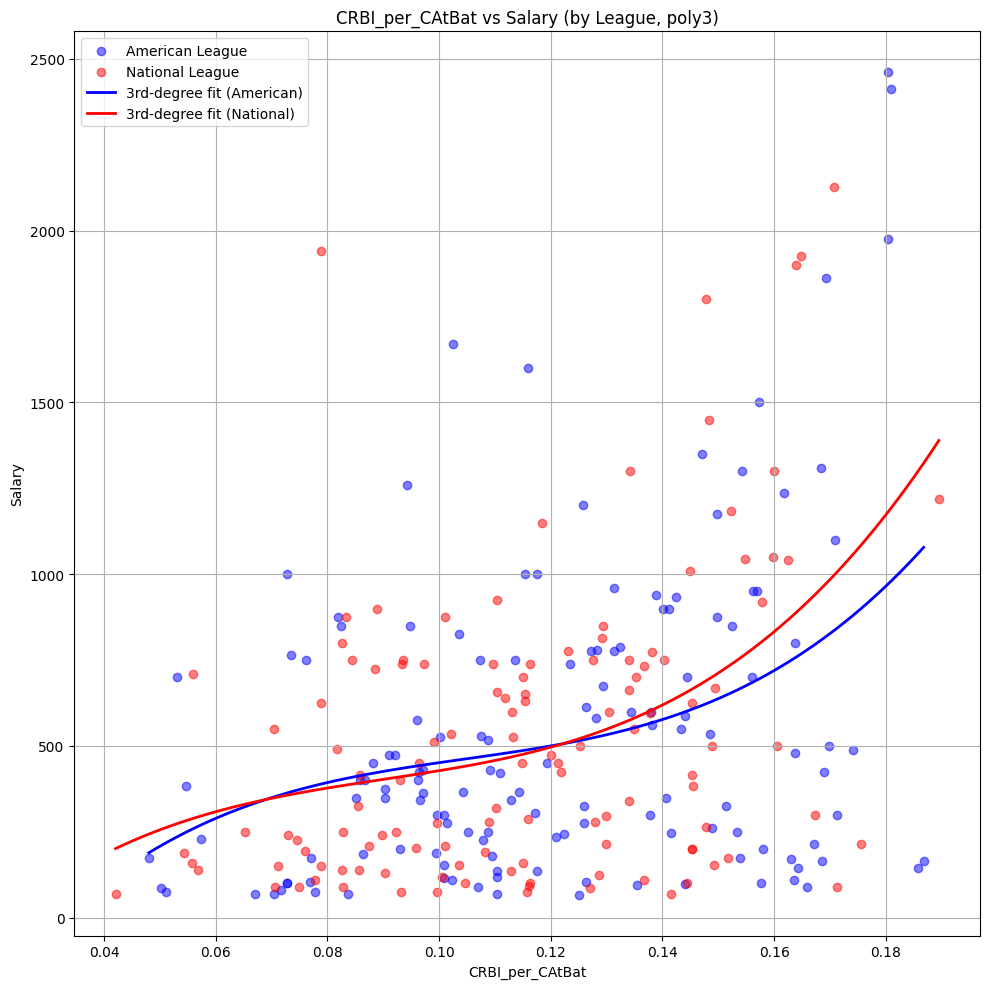

In [398]:
# 3. 리그별로 데이터 나누기
amer = Hitters2[Hitters2['League'] == 'A']
nati = Hitters2[Hitters2['League'] == 'N']

# 4. 산점도 그리기
plt.figure(figsize=(10, 10))
plt.scatter(amer['CRBI_per_CAtBat'], amer['Salary'], color='blue', alpha=0.5, label='American League')
plt.scatter(nati['CRBI_per_CAtBat'], nati['Salary'], color='red', alpha=0.5, label='National League')

# 5. 아메리칸 리그 회귀선 (3차)
x_amer = np.linspace(amer['CRBI_per_CAtBat'].min(), amer['CRBI_per_CAtBat'].max(), 100)
coeffs_amer = np.polyfit(amer['CRBI_per_CAtBat'], amer['Salary'], deg=3)
y_amer = np.polyval(coeffs_amer, x_amer)
plt.plot(x_amer, y_amer, color='blue', linewidth=2, label='3rd-degree fit (American)')

# 6. 내셔널 리그 회귀선 (3차)
x_nati = np.linspace(nati['CRBI_per_CAtBat'].min(), nati['CRBI_per_CAtBat'].max(), 100)
coeffs_nati = np.polyfit(nati['CRBI_per_CAtBat'], nati['Salary'], deg=3)
y_nati = np.polyval(coeffs_nati, x_nati)
plt.plot(x_nati, y_nati, color='red', linewidth=2, label='3rd-degree fit (National)')

# 7. 마무리
plt.xlabel("CRBI_per_CAtBat")
plt.ylabel("Salary")
plt.title("CRBI_per_CAtBat vs Salary (by League, poly3)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

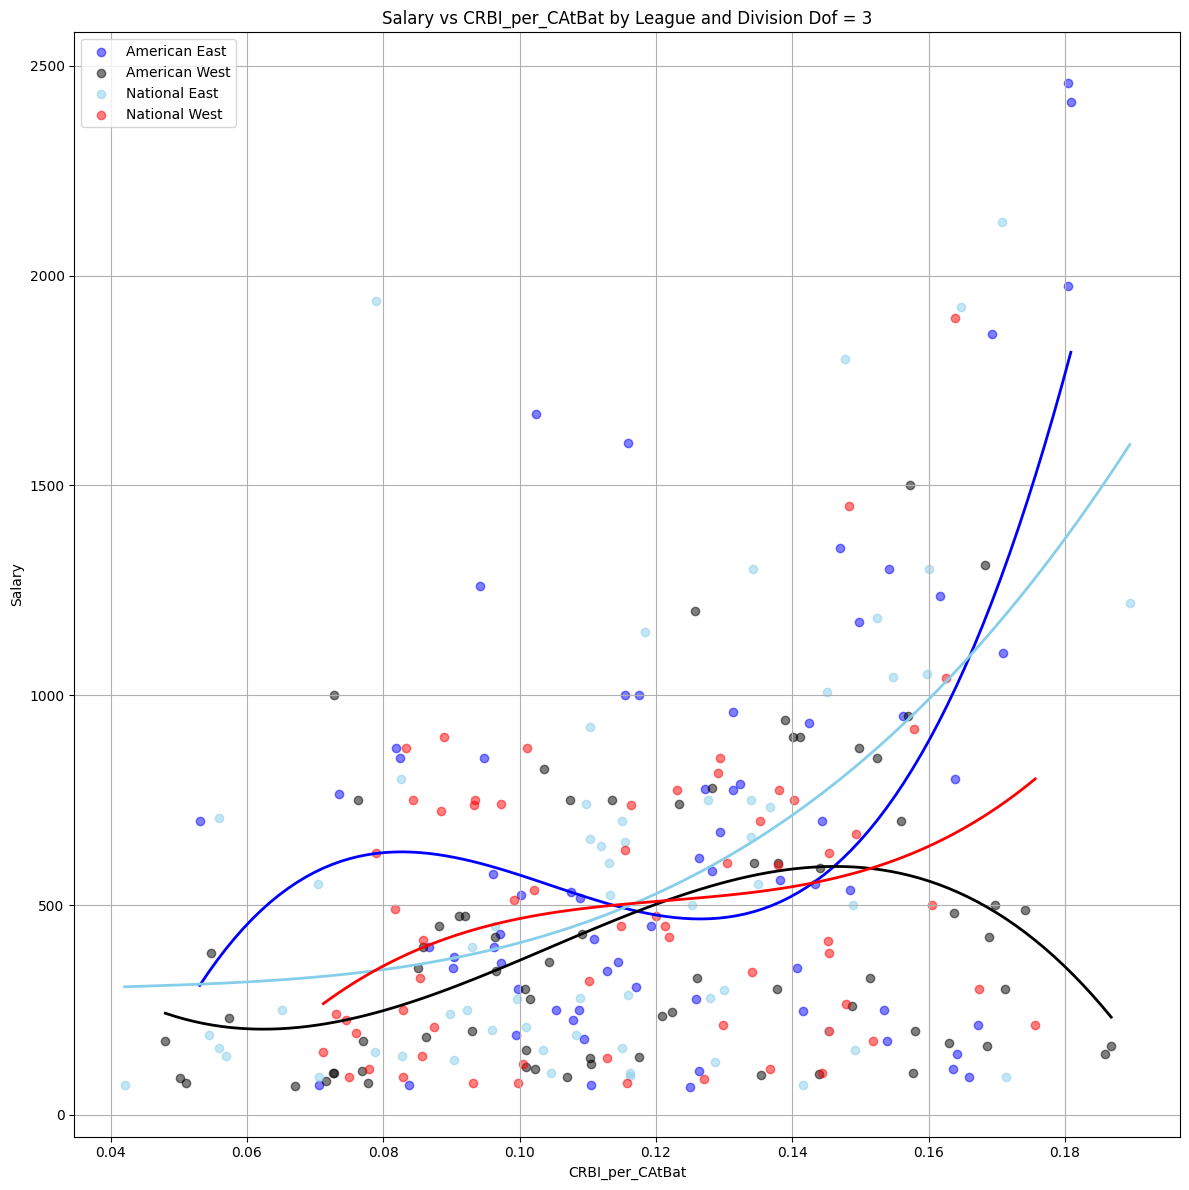

In [399]:
groups = {
    "American_East": Hitters2[(Hitters2['League'] == 'A') & (Hitters2['Division'] == 'E')],
    "American_West": Hitters2[(Hitters2['League'] == 'A') & (Hitters2['Division'] == 'W')],
    "National_East": Hitters2[(Hitters2['League'] == 'N') & (Hitters2['Division'] == 'E')],
    "National_West": Hitters2[(Hitters2['League'] == 'N') & (Hitters2['Division'] == 'W')],
}

colors = {
    "American_East": 'blue',
    "American_West": 'black',
    "National_East": 'skyblue',
    "National_West": 'red'
}
labels = {
    "American_East": 'American East',
    "American_West": 'American West',
    "National_East": 'National East',
    "National_West": 'National West'
}

# 4. 시각화
plt.figure(figsize=(12, 12))
for key, data in groups.items():
    plt.scatter(data['CRBI_per_CAtBat'], data["Salary"], color=colors[key], alpha=0.5, label=labels[key])

    # 회귀선 (3차 다항)
    x = np.linspace(data['CRBI_per_CAtBat'].min(), data['CRBI_per_CAtBat'].max(), 100)
    coeffs = np.polyfit(data['CRBI_per_CAtBat'], data["Salary"], deg=3)
    y = np.polyval(coeffs, x)
    plt.plot(x, y, color=colors[key], linewidth=2)

# 5. 마무리
plt.xlabel('CRBI_per_CAtBat')
plt.ylabel("Salary")
plt.title("Salary vs CRBI_per_CAtBat by League and Division Dof = 3")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

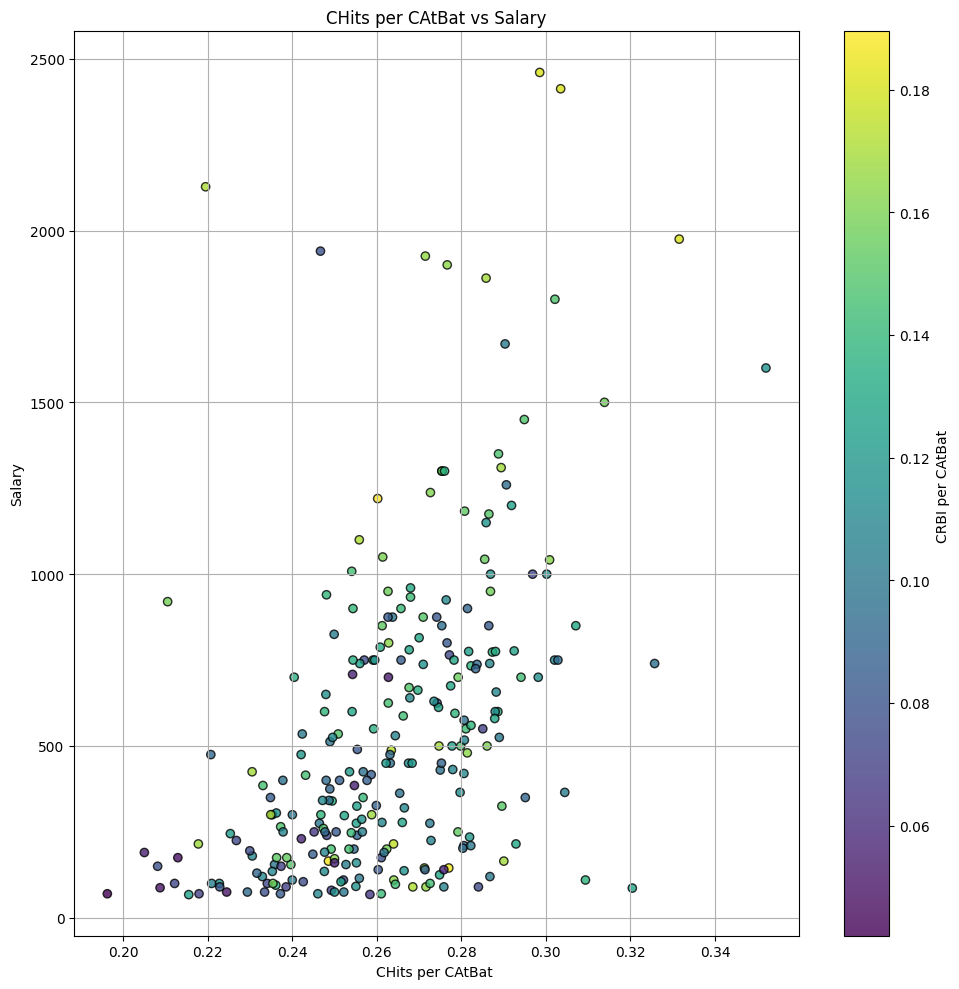

In [400]:

# 3. 시각화: 누적 타율 vs 연봉, 색상은 누적 타점률
plt.figure(figsize=(10, 10))
scatter = plt.scatter(
    Hitters2["CHits_per_CAtBat"],
    Hitters2["Salary"],
    c=Hitters2["CRBI_per_CAtBat"],
    cmap="viridis",  # 색상 맵: 낮은 값은 연하고 높은 값은 진함
    alpha=0.8,
    edgecolor="k"
)
cbar = plt.colorbar(scatter)
cbar.set_label("CRBI per CAtBat ")

plt.xlabel("CHits per CAtBat ")
plt.ylabel("Salary")
plt.title("CHits per CAtBat vs Salary")
plt.grid(True)
plt.tight_layout()
plt.show()

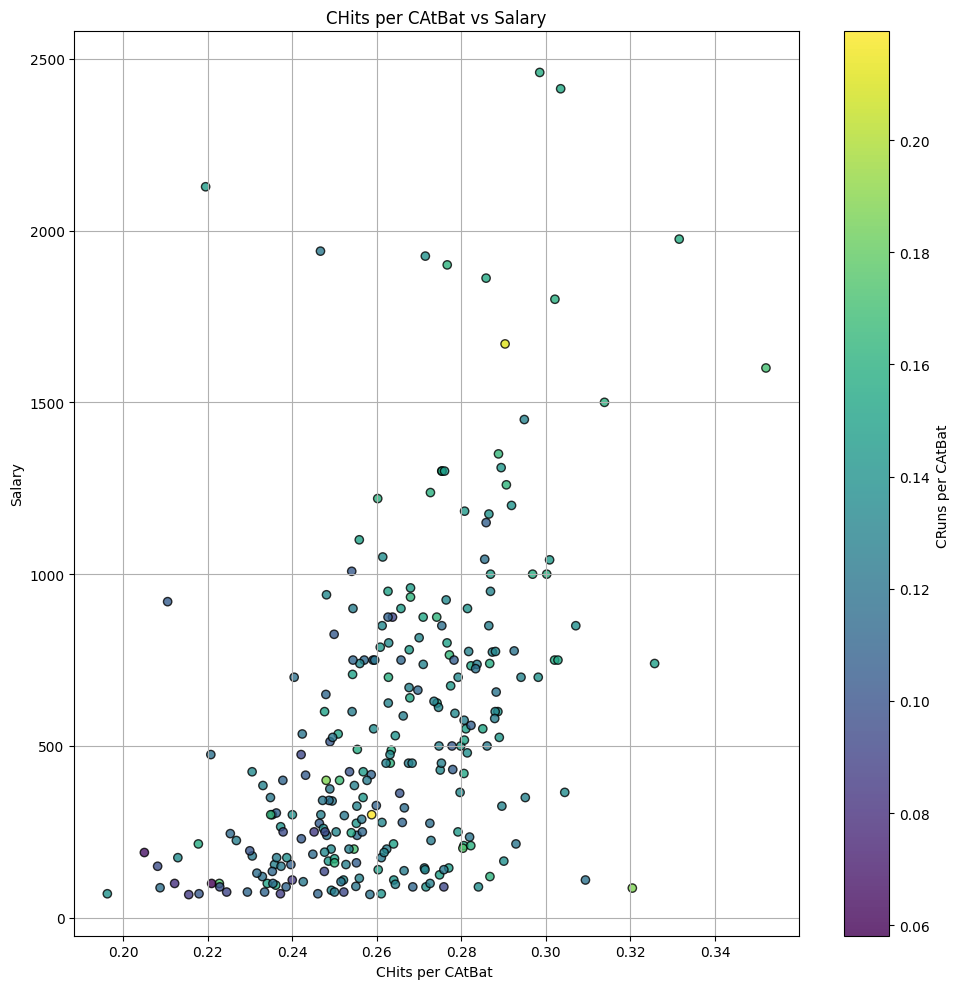

In [401]:
# 3. 시각화: 누적 타율 vs 연봉, 색상은 누적 득점률
plt.figure(figsize=(10, 10))
scatter = plt.scatter(
    Hitters2["CHits_per_CAtBat"],
    Hitters2["Salary"],
    c=Hitters2["CRuns_per_CAtBat"],
    cmap="viridis",  # 색상 맵: 낮은 값은 연하고 높은 값은 진함
    alpha=0.8,
    edgecolor="k"
)
cbar = plt.colorbar(scatter)
cbar.set_label("CRuns per CAtBat ")

plt.xlabel("CHits per CAtBat ")
plt.ylabel("Salary")
plt.title("CHits per CAtBat vs Salary")
plt.grid(True)
plt.tight_layout()
plt.show()

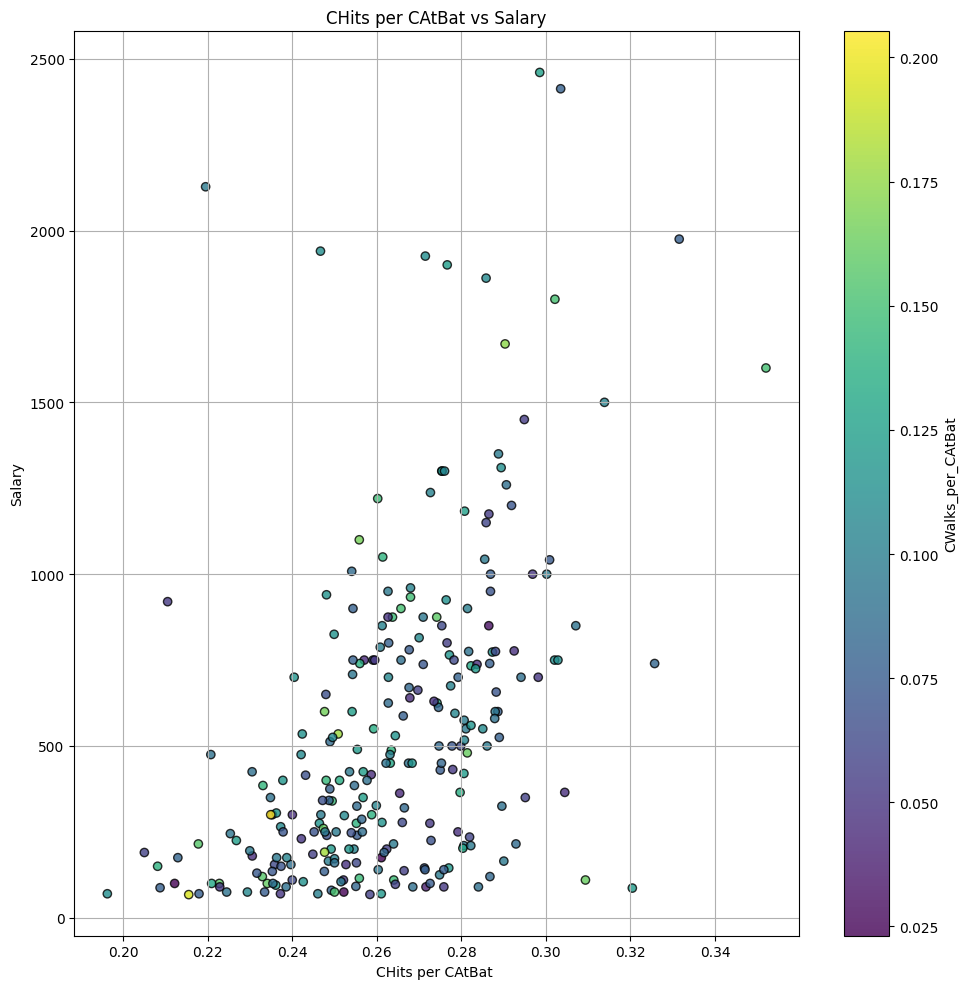

In [402]:

# 3. 시각화: 타율 vs 연봉, 색상은 타점률
plt.figure(figsize=(10, 10))
scatter = plt.scatter(
    Hitters2["CHits_per_CAtBat"],
    Hitters2["Salary"],
    c=Hitters2['CWalks_per_CAtBat'],
    cmap="viridis",  # 색상 맵: 낮은 값은 연하고 높은 값은 진함
    alpha=0.8,
    edgecolor="k"
)
cbar = plt.colorbar(scatter)
cbar.set_label('CWalks_per_CAtBat')

plt.xlabel("CHits per CAtBat ")
plt.ylabel("Salary")
plt.title("CHits per CAtBat vs Salary")
plt.grid(True)
plt.tight_layout()
plt.show()

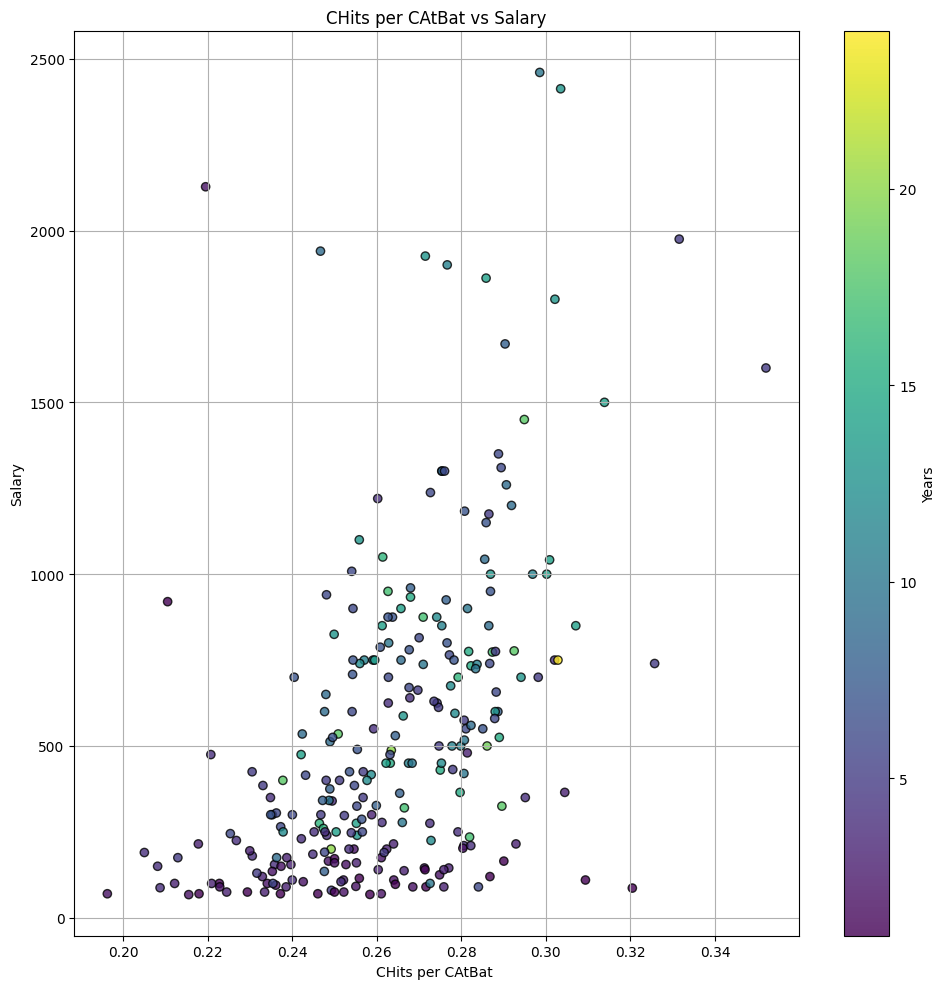

In [403]:

# 3. 시각화: 누적 타율 vs 연봉, 색상은 경력
plt.figure(figsize=(10, 10))
scatter = plt.scatter(
    Hitters2["CHits_per_CAtBat"],
    Hitters2["Salary"],
    c=Hitters2["Years"],
    cmap="viridis",  # 색상 맵: 낮은 값은 연하고 높은 값은 진함
    alpha=0.8,
    edgecolor="k"
)
cbar = plt.colorbar(scatter)
cbar.set_label("Years")

plt.xlabel("CHits per CAtBat ")
plt.ylabel("Salary")
plt.title("CHits per CAtBat vs Salary")
plt.grid(True)
plt.tight_layout()
plt.show()

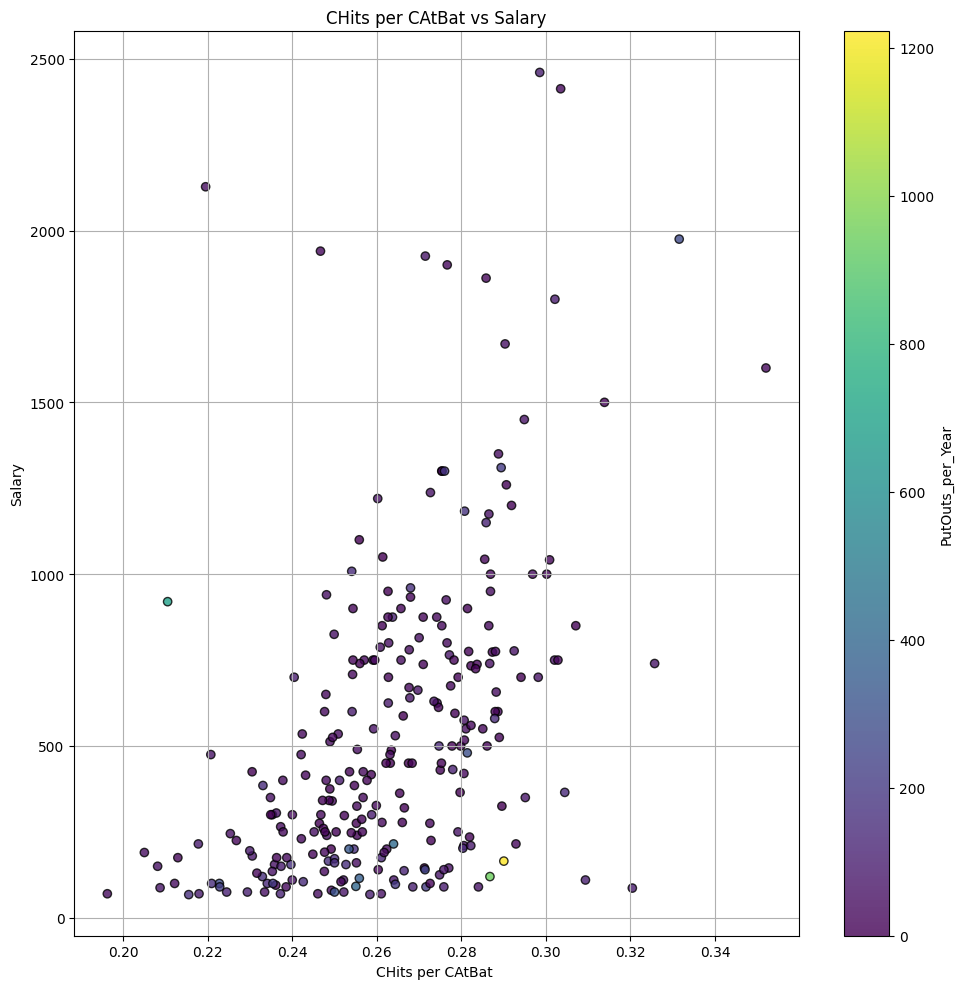

In [423]:
# 3. 시각화: 누적 타율 vs 연봉, 색상은 경력
plt.figure(figsize=(10, 10))
scatter = plt.scatter(
    Hitters2["CHits_per_CAtBat"],
    Hitters2["Salary"],
    c=Hitters2["PutOuts_per_Year"],
    cmap="viridis",  # 색상 맵: 낮은 값은 연하고 높은 값은 진함
    alpha=0.8,
    edgecolor="k"
)
cbar = plt.colorbar(scatter)
cbar.set_label("PutOuts_per_Year")

plt.xlabel("CHits per CAtBat ")
plt.ylabel("Salary")
plt.title("CHits per CAtBat vs Salary")
plt.grid(True)
plt.tight_layout()
plt.show()

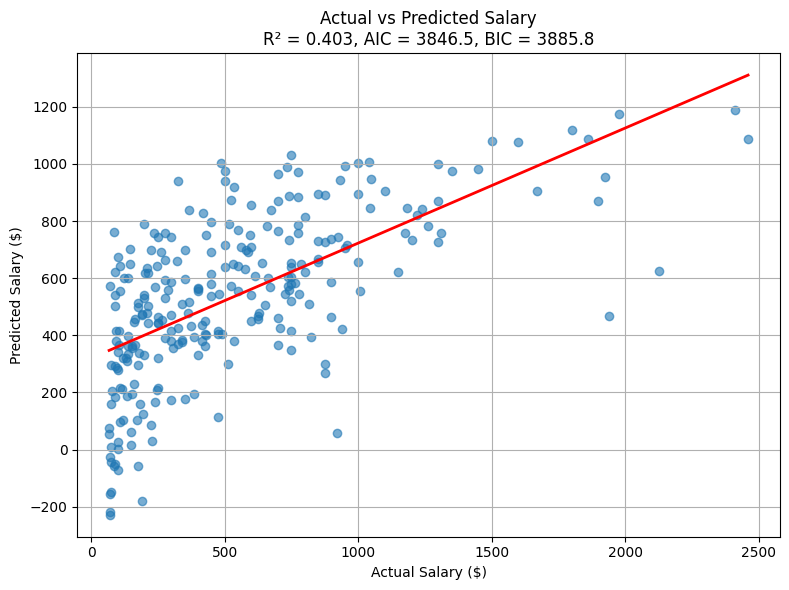

In [404]:
Hitters2['Division'] = Hitters2['Division'].astype('category').cat.codes
Hitters2['League'] = Hitters2['League'].astype('category').cat.codes
features = ['CHits_per_CAtBat', 'CRBI_per_CAtBat', 'CWalks_per_CAtBat','CRuns_per_CAtBat',
            'PutOuts_per_Year', 'Assists_per_Year', 'Errors_per_Year',
            'Division', 'League',  'Years']

# X, y 생성
X = StandardScaler().fit_transform(Hitters2[features])
y = Hitters2['Salary']
X = sm.add_constant(X)

# 회귀 모델 적합
model = sm.OLS(y, X)
results3 = model.fit()

# 예측
y_pred = results3.predict(X)


r_squared = results3.rsquared
aic = results3.aic
bic = results3.bic

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.6)

slope, intercept = np.polyfit(y, y_pred, 1)
x_vals = np.linspace(y.min(), y.max(), 100)
y_fit = slope * x_vals + intercept

plt.plot(x_vals, y_fit, 'r-', linewidth=2, label=f"Fit: y = {slope:.2f}x + {intercept:.1f}")

plt.xlabel("Actual Salary ($)")
plt.ylabel("Predicted Salary ($)")
plt.title(f"Actual vs Predicted Salary\nR² = {r_squared:.3f}, AIC = {aic:.1f}, BIC = {bic:.1f}")
plt.grid(True)
plt.tight_layout()
plt.show()

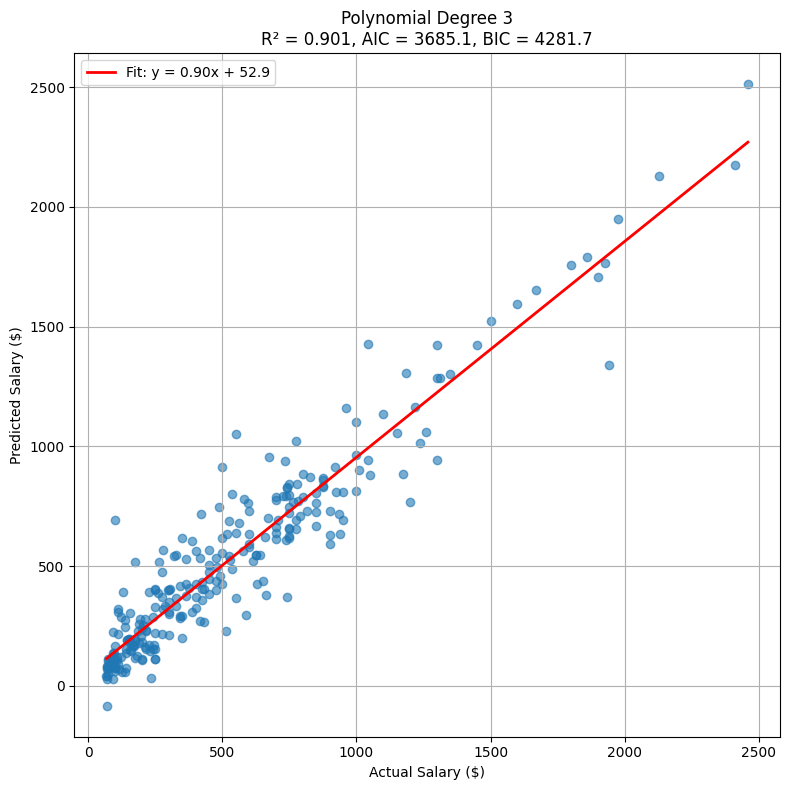

In [405]:
numeric_features = ['CHits_per_CAtBat', 'CRBI_per_CAtBat', 'CWalks_per_CAtBat','CRuns_per_CAtBat',
                    'PutOuts_per_Year', 'Assists_per_Year', 'Errors_per_Year', 'Years']
dummy_features = ['Division', 'League']

X_numeric = Hitters2[numeric_features]
X_dummies = Hitters2[dummy_features]

# 다항항 생성 (수치형만)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly_numeric = poly.fit_transform(X_numeric)

# 다항항 + 더미 결합
X_combined = np.hstack([X_poly_numeric, X_dummies.values])

# 표준화 + 상수항
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)
X_scaled_const = sm.add_constant(X_scaled)

# 회귀 학습
y = Hitters2['Salary']
model = sm.OLS(y, X_scaled_const)
results_poly3_fixed = model.fit()

# 예측 및 성능지표
y_pred = results_poly3_fixed.predict(X_scaled_const)
r_squared = results_poly3_fixed.rsquared
aic = results_poly3_fixed.aic
bic = results_poly3_fixed.bic

# 회귀선 (예측 vs 실제)
slope, intercept = np.polyfit(y, y_pred, 1)
x_vals = np.linspace(y.min(), y.max(), 100)
y_fit = slope * x_vals + intercept

# 시각화
plt.figure(figsize=(8, 8))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot(x_vals, y_fit, 'r-', linewidth=2, label=f"Fit: y = {slope:.2f}x + {intercept:.1f}")
plt.xlabel("Actual Salary ($)")
plt.ylabel("Predicted Salary ($)")
plt.title(f"Polynomial Degree 3\nR² = {r_squared:.3f}, AIC = {aic:.1f}, BIC = {bic:.1f}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [406]:
design = MS(Hitters2.columns.drop(['Salary','LogSalary'])).fit(Hitters2)
Y = np.array(Hitters2['Salary'])
X = design.transform(Hitters2)
sigma2 = OLS(Y,X).fit().scale
neg_Cp = partial(nCp, sigma2)

In [407]:
strategy = Stepwise.first_peak(design,
                               direction='forward',
                               max_terms=len(design.terms))

In [408]:
hitters_Cp = sklearn_selected(OLS,
                               strategy,
                               scoring=neg_Cp)
hitters_Cp.fit(Hitters2, Y)
hitters_Cp.selected_state_

('CHits_per_CAtBat',
 'CRBI_per_CAtBat',
 'CRuns_per_CAtBat',
 'Division',
 'Years')

In [409]:
y = Hitters2['Salary']
final_vars = [
  'CHits_per_CAtBat',
 'CRBI_per_CAtBat',
 'CRuns_per_CAtBat',
 'Division',
 'Years']
X = MS(final_vars).fit_transform(Hitters2)

# 회귀 모델 적합
model = sm.OLS(y, X)
results = model.fit()

# 결과 요약 출력
summarize(results)

#Intercept	-1535.32	 (모든 변수가 0일 때 예측 연봉, 실제 해석보다는 절편 역할)
#Assists_per_Year	+1.64 연간 어시스트 1개 증가 → 연봉 $1,635 증가
#CHits_per_CAtBat	+6097.21 커리어 타율이 0.01 증가 → 연봉 $60,972 증가
#CRBI_per_CAtBat	+3480.36 커리어 타점률이 0.01 증가 → 연봉 $34,804 증가
#Division[W]	-134.58	서부지구 소속 → 연봉이 $134,585 낮음
#Errors_per_Year	-28.70	연간 실책 1개 증가 → 연봉 $28,705 감소
#Years	+19.89	경력 1년 증가 → 연봉 $19,886 증가

,coef,std err,t,P>|t|
intercept,-1633.1830,256.313,-6.372,0.000
CHits_per_CAtBat,5214.3704,1096.926,4.754,0.000
CRBI_per_CAtBat,2749.5084,725.202,3.791,0.000
CRuns_per_CAtBat,2718.1760,1116.952,2.434,0.016
Division,-123.7347,44.525,-2.779,0.006
Years,24.5769,4.900,5.015,0.000


In [410]:
X = Hitters2[[
   'CHits_per_CAtBat',
 'CRBI_per_CAtBat',
 'CRuns_per_CAtBat',
 'Division',
 'Years'
]]

# 5. 상수항 추가
X_with_const = sm.add_constant(X)

# 6. VIF 계산
vif_df = pd.DataFrame()
vif_df["Variable"] = X_with_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                 for i in range(X_with_const.shape[1])]
vif_df

,Variable,VIF
0,const,134.738270
1,CHits_per_CAtBat,1.385976
2,CRBI_per_CAtBat,1.126738
3,CRuns_per_CAtBat,1.281588
4,Division,1.016119
5,Years,1.127406


In [411]:
design = MS(Hitters2.columns.drop(['LogSalary', 'Salary'])).fit(Hitters2)
Y = np.array(Hitters2['LogSalary'])
X = design.transform(Hitters2)
sigma2 = OLS(Y, X).fit().scale

In [412]:
neg_Cp = partial(nCp, sigma2)
strategy = Stepwise.first_peak(design,
                               direction='forward',
                               max_terms=len(design.terms))
hitters_Cp = sklearn_selected(OLS,
                               strategy,
                               scoring=neg_Cp)
hitters_Cp.fit(Hitters2, Y)
hitters_Cp.selected_state_

('Assists_per_Year',
 'CHits_per_CAtBat',
 'CHmRun_per_CAtBat',
 'CRBI_per_CAtBat',
 'CRuns_per_CAtBat',
 'Division',
 'Errors_per_Year',
 'Years')

In [413]:
y = Hitters2['LogSalary']
final_vars = [
  'Assists_per_Year',
 'CHits_per_CAtBat',
 'CHmRun_per_CAtBat',
 'Division',
 'Errors_per_Year',
 'Years'
]
X = MS(final_vars).fit_transform(Hitters2)

# 회귀 모델 적합
model = sm.OLS(y, X)
results = model.fit()

# 결과 요약 출력
summarize(results)

#Intercept	1.8990		기준선 연봉: exp(1.899) ≈ $6,683
#Assists_per_Year	0.0037		연간 어시스트 1개 증가 → 연봉 약 0.37% 증가
#CHits_per_CAtBat	13.2338		누적 타율이 0.01 증가 → 연봉 약 14.1% 증가 (exp(0.1323) ≈ 1.141)
#CHmRun_per_CAtBat	10.7088		누적 홈런률 0.01 증가 → 연봉 약 11.3% 증가 (exp(0.1071) ≈ 1.113)
#Division[W]	-0.1910	서부지구 소속 → 연봉 약 17.4% 낮음 (exp(-0.191) ≈ 0.826)
#Errors_per_Year	-0.0826	연간 실책 1개 증가 → 연봉 약 7.9% 감소 (exp(-0.0826) ≈ 0.921)
#Years	0.0631	경력 1년 증가 → 연봉 약 6.5% 증가 (exp(0.0631) ≈ 1.065)

,coef,std err,t,P>|t|
intercept,1.8990,0.470,4.044,0.000
Assists_per_Year,0.0037,0.001,3.049,0.003
CHits_per_CAtBat,13.2338,1.777,7.446,0.000
CHmRun_per_CAtBat,10.7088,2.692,3.978,0.000
Division,-0.1910,0.080,-2.391,0.018
Errors_per_Year,-0.0826,0.019,-4.356,0.000
Years,0.0631,0.010,6.394,0.000


In [414]:
X = Hitters2[[
  'Assists_per_Year',
 'CHits_per_CAtBat',
 'CHmRun_per_CAtBat',
 'Division',
 'Errors_per_Year',
 'Years'
]]

# 5. 상수항 추가
X_with_const = sm.add_constant(X)

# 6. VIF 계산
vif_df = pd.DataFrame()
vif_df["Variable"] = X_with_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                 for i in range(X_with_const.shape[1])]
vif_df

,Variable,VIF
0,const,139.739676
1,Assists_per_Year,2.264625
2,CHits_per_CAtBat,1.124270
3,CHmRun_per_CAtBat,1.097836
4,Division,1.011092
5,Errors_per_Year,2.444317
6,Years,1.412655


In [415]:
Hitters3 = load_data ('Hitters')
Hitters3 = Hitters3.dropna() # 결측값 있는 행 전체 제거

#  한 시즌 기록 기반 비율 변수 생성
Hitters3['Hits_per_AtBat'] = Hitters3['Hits'] / Hitters3['AtBat']
Hitters3['HmRun_per_AtBat'] = Hitters3['HmRun'] / Hitters3['AtBat']
Hitters3['RBI_per_AtBat'] = Hitters3['RBI'] / Hitters3['AtBat']
Hitters3['Walks_per_AtBat'] = Hitters3['Walks'] / Hitters3['AtBat']
Hitters3['Runs_per_AtBat'] = Hitters3['Runs'] / Hitters3['AtBat']


#  연평균 수비 지표 생성
Hitters3['PutOuts_per_Year'] = Hitters3['PutOuts'] / Hitters3['Years']
Hitters3['Assists_per_Year'] = Hitters3['Assists'] / Hitters3['Years']
Hitters3['Errors_per_Year'] = Hitters3['Errors'] / Hitters3['Years']

In [416]:
Hitters3 = Hitters3.drop(columns=['AtBat', 'Hits', 'HmRun','Runs', 'RBI','Walks','CAtBat', 'CHits', 'CHmRun','CRuns', 'CRBI','CWalks', 'PutOuts', 'Assists' , 'Errors','NewLeague'])

In [417]:
Hitters3

,Years,League,Division,Salary,Hits_per_AtBat,HmRun_per_AtBat,RBI_per_AtBat,Walks_per_AtBat,Runs_per_AtBat,PutOuts_per_Year,Assists_per_Year,Errors_per_Year
1,14,N,W,475.0,0.257143,0.022222,0.120635,0.123810,0.076190,45.142857,3.071429,0.714286
2,3,A,W,480.0,0.271399,0.037578,0.150313,0.158664,0.137787,293.333333,27.333333,4.666667
3,11,N,E,500.0,0.284274,0.040323,0.157258,0.074597,0.131048,18.181818,1.000000,0.272727
4,2,N,E,91.5,0.271028,0.031153,0.130841,0.093458,0.121495,402.500000,20.000000,2.000000
5,11,A,W,750.0,0.284512,0.006734,0.085859,0.058923,0.124579,25.636364,38.272727,2.272727
...,...,...,...,...,...,...,...,...,...,...,...,...
317,5,N,E,700.0,0.255533,0.014085,0.096579,0.074447,0.130785,65.000000,1.800000,0.600000
318,12,A,E,875.0,0.276423,0.010163,0.101626,0.191057,0.154472,26.083333,31.750000,1.666667
319,6,A,W,385.0,0.265263,0.006316,0.090526,0.109474,0.128421,6.166667,18.833333,1.166667
320,8,A,E,960.0,0.251309,0.015707,0.104712,0.136126,0.148342,164.250000,16.375000,1.500000


In [418]:
Hitters3.columns

Index(['Years', 'League', 'Division', 'Salary', 'Hits_per_AtBat',
       'HmRun_per_AtBat', 'RBI_per_AtBat', 'Walks_per_AtBat', 'Runs_per_AtBat',
       'PutOuts_per_Year', 'Assists_per_Year', 'Errors_per_Year'],
      dtype='object')

In [419]:
# Hitters3 MLR
y = Hitters3['Salary']

# 독립 변수: Salary 제외한 모든 열 사용
features = list(Hitters3.columns.difference(['Salary']))

# 디자인 행렬 생성
X = MS(features).fit_transform(Hitters3)

# 회귀 모델 적합
model = sm.OLS(y, X)
results3 = model.fit()

# 결과 요약 출력
summarize(results3)
# 한시즌 기록으로 salary를 추론하는것은 통계적으로 유의하지 않음 

,coef,std err,t,P>|t|
intercept,-271.9708,230.948,-1.178,0.240
Assists_per_Year,1.3493,0.770,1.753,0.081
Division[W],-161.6029,50.284,-3.214,0.001
Errors_per_Year,-28.5013,12.304,-2.316,0.021
Hits_per_AtBat,1816.4736,1009.404,1.800,0.073
HmRun_per_AtBat,2421.5056,2647.718,0.915,0.361
League[N],13.4299,51.165,0.262,0.793
PutOuts_per_Year,0.3084,0.242,1.276,0.203
RBI_per_AtBat,-312.2870,1171.111,-0.267,0.790
Runs_per_AtBat,579.3891,1211.572,0.478,0.633


In [420]:
X = Hitters3[[
 'Years', 'Hits_per_AtBat',
       'HmRun_per_AtBat', 'RBI_per_AtBat', 'Walks_per_AtBat', 'Runs_per_AtBat',
       'PutOuts_per_Year', 'Assists_per_Year', 'Errors_per_Year'
]]

# 5. 상수항 추가
X_with_const = sm.add_constant(X)

# 6. VIF 계산
vif_df = pd.DataFrame()
vif_df["Variable"] = X_with_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                 for i in range(X_with_const.shape[1])]
vif_df

,Variable,VIF
0,const,82.528351
1,Years,1.537217
2,Hits_per_AtBat,1.720205
3,HmRun_per_AtBat,3.410246
4,RBI_per_AtBat,3.335897
5,Walks_per_AtBat,1.355555
6,Runs_per_AtBat,1.986290
7,PutOuts_per_Year,1.352034
8,Assists_per_Year,2.302272
9,Errors_per_Year,2.666333


C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\이동호\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2

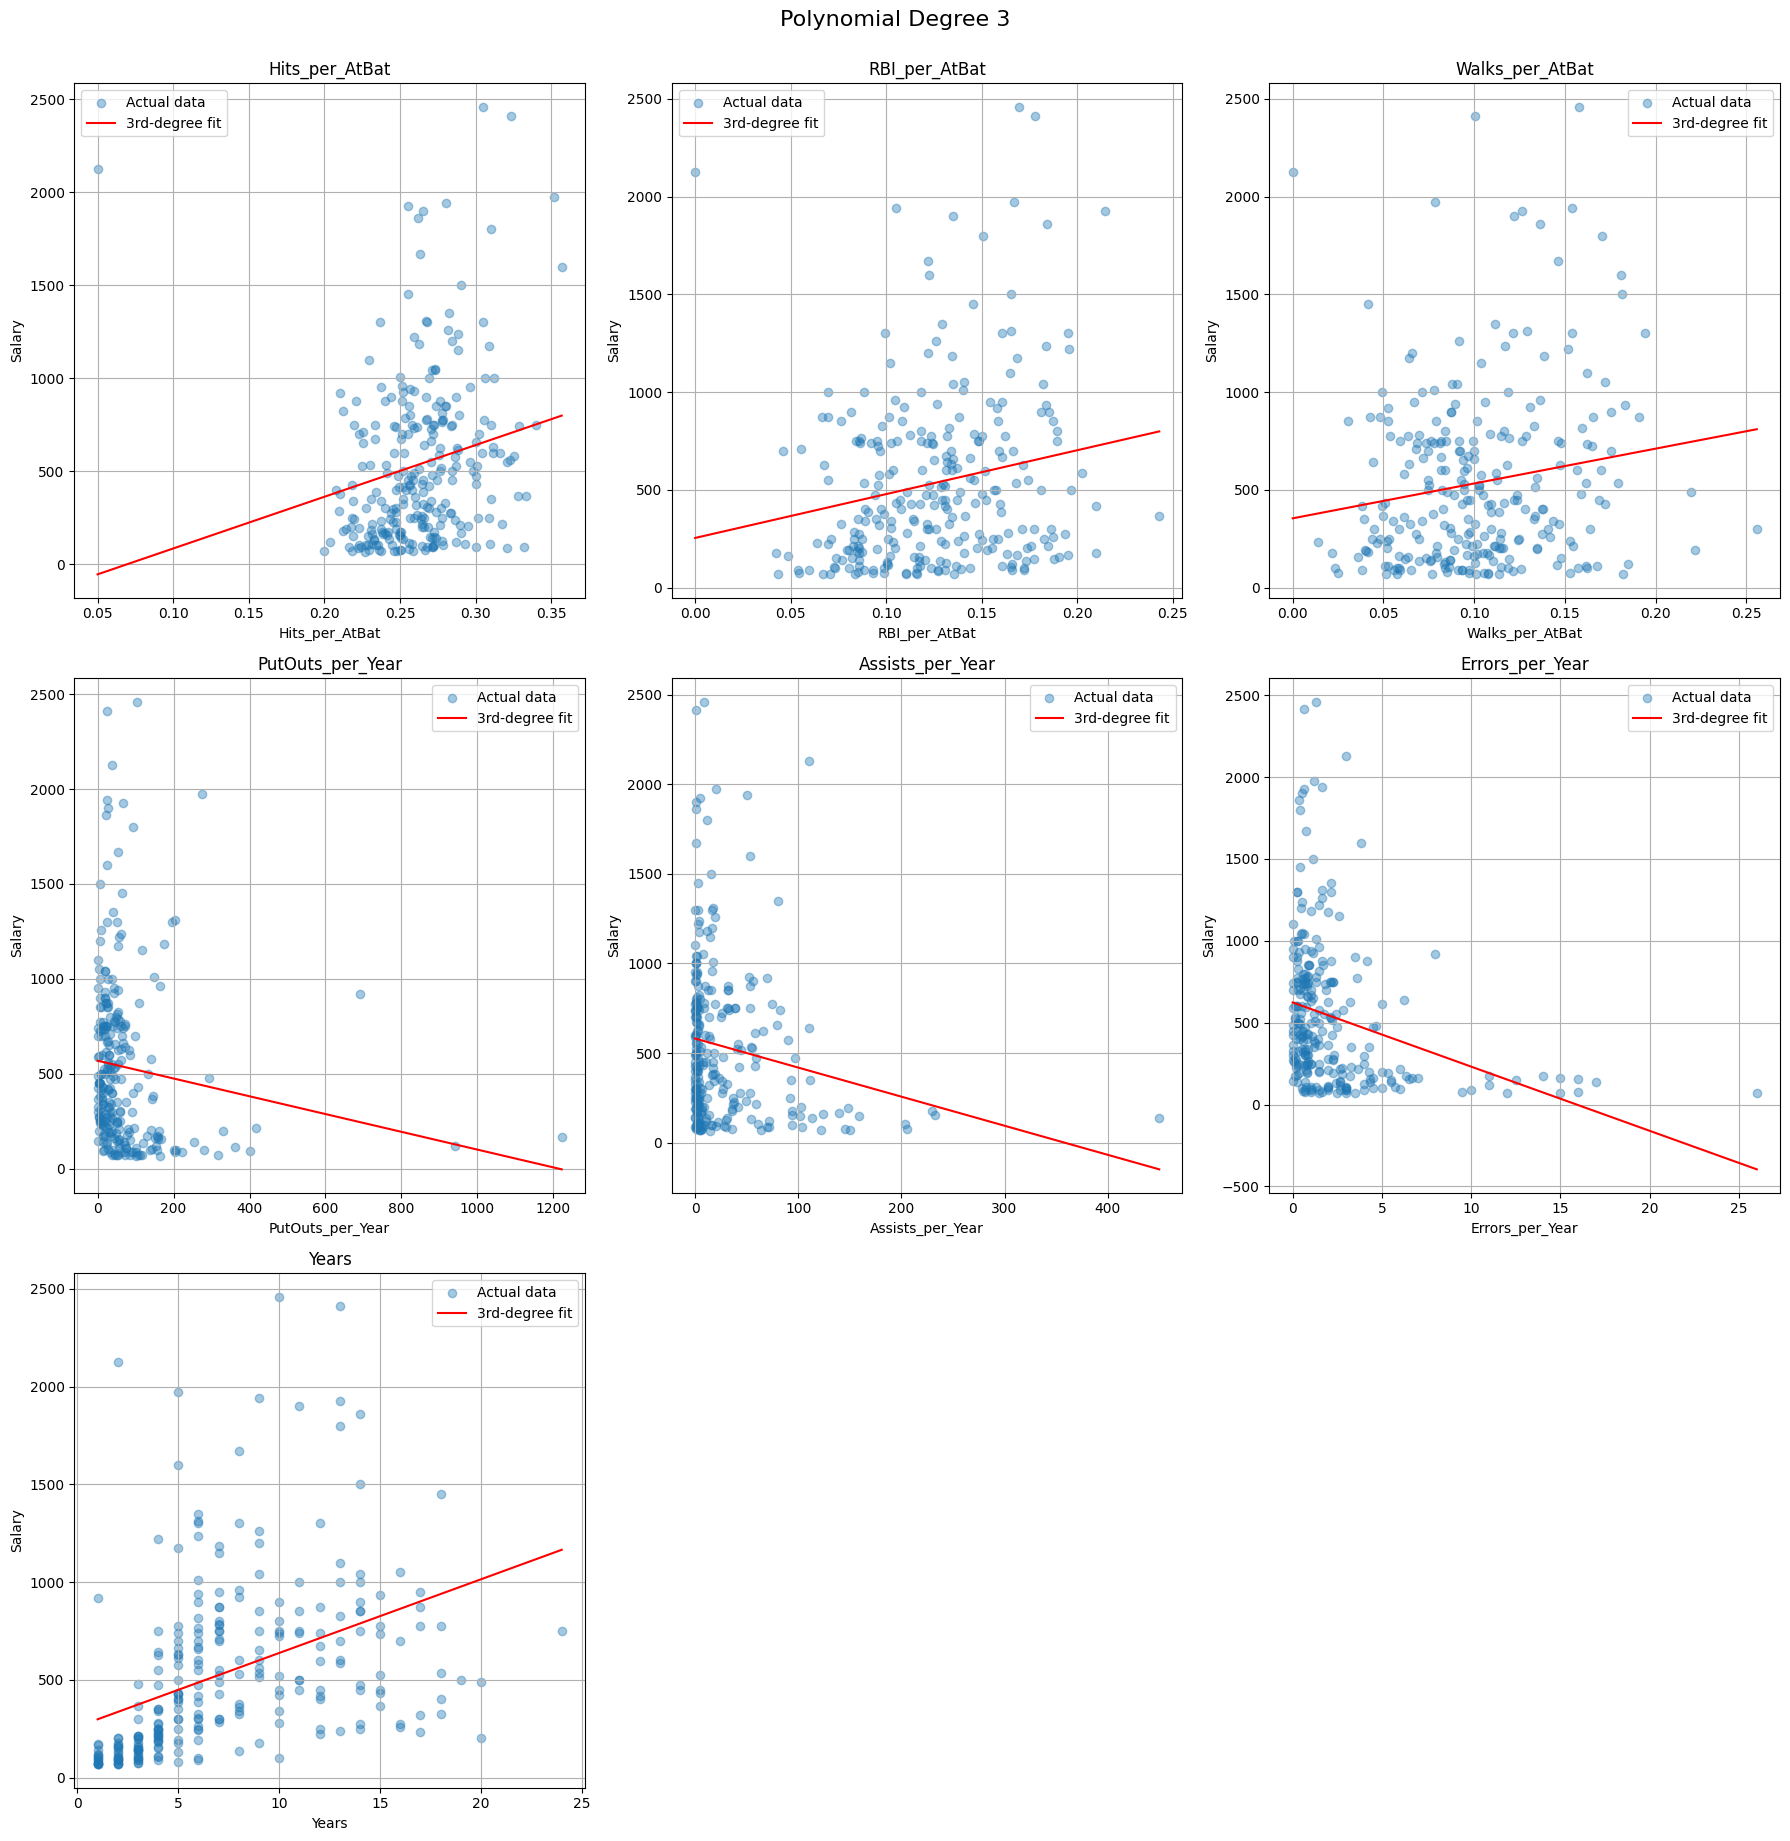

In [421]:
features = ['Hits_per_AtBat', 'RBI_per_AtBat', 'Walks_per_AtBat',
            'PutOuts_per_Year', 'Assists_per_Year', 'Errors_per_Year',
            'Years']

y = Hitters3['Salary']

# subplot 구성
n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 6))
axes = axes.flatten()

# 각 변수에 대해 반복
for i, feature in enumerate(features):
    x = Hitters3[[feature]]
    
    # 다항 특성 생성 및 모델 학습
    poly = PolynomialFeatures(degree=1)
    X_poly = poly.fit_transform(x)
    model = LinearRegression().fit(X_poly, y)

    # 시각화용 x 구간
    x_plot = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    x_poly_plot = poly.transform(x_plot)
    y_plot = model.predict(x_poly_plot)

    # 플롯 그리기
    ax = axes[i]
    ax.scatter(x, y, alpha=0.4, label='Actual data')
    ax.plot(x_plot, y_plot, color='red', label='3rd-degree fit')
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel('Salary')
    ax.legend()
    ax.grid(True)

# 남은 빈 plot 지우기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Polynomial Degree 3", fontsize=16, y=1.02)
plt.show()
# 현재 시즌을 지표로 연봉을 추측하는것은 누적 지표로 추측하는것에 비해 정확도가 낮음